# git log/history
<br>  

### References
- [Visualizing Code: Polyglot Notebooks Repository (YouTube)](https://youtu.be/ipOpToPS-PY?si=3doePt2cp-LgEUmt)
- [gitstractor (GitHub)](https://github.com/IntegerMan/gitstractor)
- [Neo4j Python Driver](https://neo4j.com/docs/api/python-driver/current)

In [1]:
import os
import numpy as np
import pandas as pd
#pd.options.mode.copy_on_write = True

In [2]:
from neo4j import GraphDatabase
from plotly import graph_objects as plotly_graph_objects
from plotly.express import colors as plotly_colors
from plotly.subplots import make_subplots

In [3]:
# To be able to distinguish between command line execution and Jupyter notebook execution
# we need to check if the environment variable NBCONVERT is set.
# The command line execution is required to take care of setting NBCONVERT.

# Note: Even if it would be great to retain the interactivity of plotly Treemap plots (e.g. clicking into details)
#       for command line executed notebooks (via nbconvert),
#       it would require to execute the notebook twice: Once including interactivity and once for static Markdown and PDF.
#       Therefore, command line executed notebooks (nbconvert) will contain static graphics (here using svg).
def is_command_line_execution():
    return 'NBCONVERT_PATH' in os.environ

def get_offline_path():
    return os.environ.get('NBCONVERT_PATH', '')

default_renderer = None

if is_command_line_execution():
    print("Command line execution (CLI mode): Yes")
    default_renderer = 'svg' # SVG is the default renderer for static (non interactive) pictures for command line execution
else:
    print("Command line execution (CLI mode): No")

Command line execution (CLI mode): Yes


In [4]:
# Please set the environment variable "NEO4J_INITIAL_PASSWORD" in your shell 
# before starting jupyter notebook to provide the password for the user "neo4j". 
# It is not recommended to hardcode the password into jupyter notebook for security reasons.

driver = GraphDatabase.driver(uri="bolt://localhost:7687", auth=("neo4j", os.environ.get("NEO4J_INITIAL_PASSWORD")))
driver.verify_connectivity()

In [5]:
def get_cypher_query_from_file(cypher_file_name : str):
    with open(cypher_file_name) as file:
        return ' '.join(file.readlines())


def query_cypher_to_data_frame(filename : str, limit: int = -1):
    """
    Execute the Cypher query of the given file and returns the result.
    filename : str : The name of the file containing the Cypher query
    limit : int : The optional limit of rows to optimize the query. Default = -1 = no limit
    """
    cypher_query = get_cypher_query_from_file(filename)
    if limit > 0:
        cypher_query = "{query}\nLIMIT {row_limit}".format(query = cypher_query, row_limit = limit)
    records, summary, keys = driver.execute_query(cypher_query)
    return pd.DataFrame([r.values() for r in records], columns=keys)


def query_first_non_empty_cypher_to_data_frame(*filenames : str, limit: int = -1):
    """
    Executes the Cypher queries of the given files and returns the first result that is not empty.
    If all given file names result in empty results, the last (empty) result will be returned.
    By additionally specifying "limit=" the "LIMIT" keyword will appended to query so that only the first results get returned.
    """    
    result=pd.DataFrame()
    for filename in filenames:
        result=query_cypher_to_data_frame(filename, limit)
        if not result.empty:
            return result
    return result

In [6]:
#The following cell uses the build-in %html "magic" to override the CSS style for tables to a much smaller size.
#This is especially needed for PDF export of tables with multiple columns.

In [7]:
%%html
<style>
/* CSS style for smaller dataframe tables. */
.dataframe th {
    font-size: 8px;
}
.dataframe td {
    font-size: 8px;
}
</style>

In [8]:
# Pandas DataFrame Display Configuration
pd.set_option('display.max_colwidth', 500)

## Git History - Directory Commit Statistics

In [9]:
# --------------------------------------------------------------------------------
# Shared Treemap Layout Functions and Constants
# --------------------------------------------------------------------------------

In [10]:
# Base settings for Plotly Treemap

plotly_main_layout_base_settings = dict(
    margin=dict(t=80, l=15, r=15, b=15),
)
plotly_treemap_layout_base_settings = dict(
    **plotly_main_layout_base_settings
)
plotly_bar_layout_base_settings = dict(
    **plotly_main_layout_base_settings
)
plotly_treemap_figure_show_settings = dict(
    renderer="svg" if is_command_line_execution() else None,
    width=680 if is_command_line_execution() else 1080,
    height=680 if is_command_line_execution() else 1080,
    config={'scrollZoom': False, 'displaylogo': False, 'displayModeBar': False} if is_command_line_execution() else {}
)

plotly_treemap_marker_base_style = dict(
    cornerradius=5, 
)

plotly_treemap_marker_base_colorscale = dict(
    **plotly_treemap_marker_base_style,
    colorscale='Hot_r', #  Hot_r, ice_r, Viridis_r, speed_r, haline_r, thermal_r, Plasma_r, solar_r, Electric_r, Blackbody_r, deep_r, Turbo_r, amp, Reds, Blackbody_r, RdGy_r, RdBu_r
)

In [11]:
def get_plotly_figure_write_image_settings(name: str):
    """
    Returns the settings for the plotly figure write_image method
    :param name: Name of the figure
    :return: Dictionary with settings for the write_image method
    """
    return dict(
        file=get_offline_path() + "/" + name + ".svg", 
        format="svg", 
        width=1080, 
        height=1080
    )

In [12]:
def create_treemap_commit_statistics_settings(data_frame: pd.DataFrame):
    """
    Creates a Plotly Treemap with the given settings and data frame.
    data_frame : pd.DataFrame : The input data frame
    return :plotly_graph_objects.Treemap : The prepared Plotly Treemap
    """
    return plotly_graph_objects.Treemap(
        labels=data_frame['directoryName'],
        parents=data_frame['directoryParentPath'],
        ids=data_frame['directoryPath'],
        customdata=data_frame[['fileCount', 'mostFrequentFileExtension', 'commitCount', 'authorCount', 'mainAuthor', 'secondAuthor','lastCommitDate', 'daysSinceLastCommit', 'lastCreationDate', 'daysSinceLastCreation', 'lastModificationDate', 'daysSinceLastModification', 'directoryPath']],
        hovertemplate='<b>%{label}</b><br>Files: %{customdata[0]} (%{customdata[1]})<br>Commits: %{customdata[2]}<br>Authors: %{customdata[4]},  %{customdata[5]},.. (%{customdata[3]})<br>Last Commit: %{customdata[6]} (%{customdata[7]} days ago)<br>Last Created: %{customdata[8]} (%{customdata[9]} days ago)<br>Last Modified: %{customdata[10]} (%{customdata[11]} days ago)<br>Path: %{customdata[12]}',
        maxdepth=-1,
        root_color="lightgrey",
        marker=dict(**plotly_treemap_marker_base_style),
    )

In [13]:
def create_rank_colorbar_for_graph_objects_treemap_marker(data_frame: pd.DataFrame, name_column: str, rank_column: str):
    """
    Creates a plotly graph_objects.Treemap marker object for a colorbar representing ranked names.
    data_frame : pd.DataFrame : The DataFrame that contains the name and the count column
    name_column : str : The name of the column containing the ranking 
    rank_column : str : The name of the column containing the ranking 
    return : plotly_graph_objects.treemap.Marker : The created Marker object
    """
    # The rank is inverted so that the first rank is shown on the top of the colorbar.
    inverse_ranked = data_frame[rank_column].max() + 1 - data_frame[rank_column]

    return dict(
        cornerradius=5, 
        colors=inverse_ranked,
        colorscale=plotly_colors.qualitative.G10, #favorites: plotly_colors.qualitative.G10, Blackbody, ice, haline, hot
        colorbar=dict(
            title="Rank",
            tickmode="array",
            ticktext=data_frame[name_column],
            tickvals=inverse_ranked,
            tickfont_size=10
        ),
    )

In [14]:
# --------------------------------------------------------------------------------
# Shared Visualization Data Preparation Functions
# --------------------------------------------------------------------------------

In [15]:
def add_quantile_limited_column(input_data_frame : pd.DataFrame, column_name : str, quantile : float = 0.95) -> pd.DataFrame:
    """
    Limits the values of the given column in the input data frame to the given quantile.
    The values are not filtered out but set to the limited (integer quantile value).
    input_data_frame : pd.DataFrame : The input data frame
    column_name : str : The name of the column to limit
    quantile : float : The quantile to limit the values to (default: 0.95)
    return : pd.DataFrame : The modified dataframe with the added column (column_name + '_limited')
    """
    data_frame=input_data_frame.copy()
    column_values = data_frame[column_name]
    column_limit = column_values.quantile(quantile)
    data_frame[column_name + '_limited'] = np.where(column_values > column_limit, column_limit, column_values)
    return data_frame

In [16]:
def add_rank_column(input_data_frame : pd.DataFrame, column_name : str) -> pd.DataFrame:
    """
    Adds a rank column ("dense" mode) to the input data frame based on the given column name.
    input_data_frame : pd.DataFrame : The input data frame
    column_name : str : The name of the column to rank
    return : pd.DataFrame : The modified dataframe with the added rank column
    """
    data_frame=input_data_frame.copy()
    data_frame[column_name + '_rank'] = data_frame[column_name].rank(ascending=True, method='dense')
    return data_frame

In [17]:
# --------------------------------------------------------------------------------
# Shared File Data Preparation Functions
# --------------------------------------------------------------------------------

In [18]:
def get_last_entry(values: pd.Series):
    """
    Get the last element of an array and converts therefore an array to a single element
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : any : The last entry
    """
    return values[-1]


def add_file_extension_column(input_dataframe: pd.DataFrame, file_path_column: str, file_extension_column: str = 'fileExtension'):
    """
    Adds a fileExtension column to the input DataFrame based on the file path column.
    input_dataframe : pd.DataFrame : The input DataFrame
    file_path_column : str : The name of the file path column
    file_extension_column : str : The name of the file extension column to be added
    return : pd.DataFrame : The DataFrame with added directory column
    """
    if file_extension_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    # What is the correct extension in the following cases?
    #  - /main/resources/META-INF/services/org.axonframework.messaging.annotation.HandlerEnhancerDefinition
    #  - MyReactComponent.test.tsx
    # Currently, it would be
    #  - HandlerEnhancerDefinition
    #  - tsx
    # which is not perfect but good enough to start with.#
    
    file_path_column_position = input_dataframe.columns.get_loc(file_path_column)
    file_extensions=input_dataframe[file_path_column].str.split('/').map(get_last_entry)
    file_extensions=file_extensions.str.split('.').map(get_last_entry)
    input_dataframe.insert(file_path_column_position + 1, file_extension_column, file_extensions)
    return input_dataframe

def remove_last_file_path_element(file_path_elements: list) -> list:
    """
    Removes the last element of the file path so that only the directory names retain.
    file_path_elements : list : The list of levels to remove
    return : list : The list of the directories
    """
    return file_path_elements[:-1] if len(file_path_elements) > 1 else ['']

def convert_path_elements_to_directories(file_path_elements: list) -> list:
    """
    Converts the file path elements into directories.
    file_path_elements : list : The list of levels to convert
    return : list : The list of directories
    """
    directories = remove_last_file_path_element(file_path_elements)
    return ['/'.join(directories[:i+1]) for i in range(len(directories))]

def add_directory_column(input_dataframe: pd.DataFrame, file_path_column: str, directory_column: str = 'directoryPath'):
    """
    Adds a directory column to the input DataFrame based on the file path column.
    input_dataframe : pd.DataFrame : The input DataFrame
    file_path_column : str : The name of the file path column
    directory_column : str : The name of the directory column to be added
    return : pd.DataFrame : The DataFrame with added directory column
    """
    if directory_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    input_dataframe.insert(0, directory_column, input_dataframe[file_path_column].str.split('/').apply(convert_path_elements_to_directories))
    input_dataframe = input_dataframe.explode(directory_column)
    return input_dataframe

def add_directory_name_column(input_dataframe: pd.DataFrame, directory_column: str = 'directoryPath', directory_name_column: str = 'directoryName'):
    """
    Adds a directory name column to the input DataFrame based on the directory column.
    input_dataframe : pd.DataFrame : The input DataFrame
    directory_column : str : The name of the directory column
    directory_name_column : str : The name of the directory name column to be added
    return : pd.DataFrame : The DataFrame with added directory name column
    """
    if directory_name_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    splitted_directories = input_dataframe[directory_column].str.rsplit('/', n=1)
    input_dataframe.insert(1, directory_name_column, splitted_directories.apply(lambda x: (x[-1])))
    return input_dataframe

def add_parent_directory_column(input_dataframe: pd.DataFrame, directory_column: str = 'directoryPath', directory_parent_column: str = 'directoryParentPath'):
    """
    Adds a directory parent column to the input DataFrame based on the directory column.
    input_dataframe : pd.DataFrame : The input DataFrame
    directory_column : str : The name of the directory column
    directory_parent_column : str : The name of the directory parent column to be added
    return : pd.DataFrame : The DataFrame with added directory parent column
    """
    if directory_parent_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    # Remove last path element from directory_column to get the directory_parent_column
    splitted_directories = input_dataframe[directory_column].str.rsplit('/', n=1)
    input_dataframe.insert(1, directory_parent_column, splitted_directories.apply(lambda x: (x[0])))
    
    # Clear parent (set to empty string) when it equal to the directory
    input_dataframe.loc[input_dataframe[directory_parent_column] == input_dataframe[directory_column], directory_parent_column] = ''
    return input_dataframe


def collect_as_array(values: pd.Series):
    """
    Just collect all values (no operation, "noop")
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : any : The second entry
    """
    return np.asanyarray(values.to_list())

def second_entry(values: pd.Series):
    """
    Returns the second entry of a list of values.
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : any : The second entry
    """
    return values.iloc[1] if len(values) > 1 else None

def get_flattened_unique_values(values: pd.Series):
    """
    Return an array of unique string values from an array of array of strings.
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return :  Series : The pandas Series of values
    """
    return np.unique(np.concatenate(values.to_list()))

def count_unique_aggregated_values(values: pd.Series):
    """
    Return the number of unique values from an array of array of strings.
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : int : The number of files
    """
    return len(np.unique(np.concatenate(values.to_list())))


def get_most_frequent_entry(input_values: pd.Series):
    """
    Flattens the array of arrays and return the most frequent entry .
    Meant to be used as an aggregation function for dataframe grouping.
    input_values : Series : The pandas Series of values
    return : str : The most frequent entry
    """
    # flatten the array of arrays 
    values = np.concatenate(input_values.to_list())
    # find frequency of each value
    values, counts = np.unique(values, return_counts=True)
    #display all values with highest frequencies
    return values[counts.argmax()]

In [19]:
# --------------------------------------------------------------------------------
# Main File Data Preparation
# --------------------------------------------------------------------------------

In [20]:
git_files_with_commit_statistics = query_cypher_to_data_frame("../cypher/GitLog/List_git_files_with_commit_statistics_by_author.cypher")

# Get all authors, their commit count and based on it their rank in a separate dataframe.
# This will then be needed to visualize the (main) author for each directory.
git_file_authors=git_files_with_commit_statistics[['author', 'commitCount']].groupby('author').aggregate(
    authorCommitCount=pd.NamedAgg(column="commitCount", aggfunc="sum"),
    ).sort_values(by='authorCommitCount', ascending=False).reset_index()
git_file_authors['authorCommitCountRank'] = git_file_authors['authorCommitCount'].rank(ascending=False, method='dense').astype(int)

# Debug
# display(git_file_authors)

# Debug
# display("1. query result ---------------------")
# display(git_files_with_commit_statistics)

# Add new column 'fileExtension' for every 'filePath'
git_files_with_commit_statistics = add_file_extension_column(git_files_with_commit_statistics, 'filePath', 'fileExtension')

# Create a separate dataframe with all unique extensions, the number of their occurrences and the rank derived from it.
git_file_extensions=git_files_with_commit_statistics['fileExtension'].value_counts().rename_axis('fileExtension').reset_index(name='fileExtensionCount')
git_file_extensions['fileExtensionCountRank'] = git_file_extensions['fileExtensionCount'].rank(ascending=False, method='dense').astype(int)

# Debug
# display(git_file_extensions)

# Add multiple rows for each file path containing all its directories paths in the new column 'directoryPath'
git_files_with_commit_statistics = add_directory_column(git_files_with_commit_statistics, 'filePath', 'directoryPath')

# Debug
# display("2. added directoryPath and fileExtension --------------")
# display(git_files_with_commit_statistics)

# Define how common non-grouped columns will be aggregated.
# Hint: maxCommitSha might not seem very useful, but it actually helps by group similar directories in the final step
common_named_aggregation = dict(
    daysSinceLastCommit=pd.NamedAgg(column="daysSinceLastCommit", aggfunc="min"),
    daysSinceLastCreation=pd.NamedAgg(column="daysSinceLastCreation", aggfunc="min"),
    daysSinceLastModification=pd.NamedAgg(column="daysSinceLastModification", aggfunc="min"),
    lastCommitDate=pd.NamedAgg(column="lastCommitDate", aggfunc="max"),
    lastCreationDate=pd.NamedAgg(column="lastCreationDate", aggfunc="max"),
    lastModificationDate=pd.NamedAgg(column="lastModificationDate", aggfunc="max"),
    maxCommitSha=pd.NamedAgg(column="maxCommitSha", aggfunc="max"),
)

# Group the git files by their directory and author and count the number of files of each directory (across all levels).
git_files_with_commit_statistics = git_files_with_commit_statistics.groupby(['directoryPath', 'author']).aggregate(
    filePaths=pd.NamedAgg(column="filePath", aggfunc=np.unique),
    firstFile=pd.NamedAgg(column="filePath", aggfunc="first"),
    fileExtensions=pd.NamedAgg(column="fileExtension", aggfunc=collect_as_array),
    commitHashes=pd.NamedAgg(column="commitHashes", aggfunc=get_flattened_unique_values),
    intermediateCommitCount=pd.NamedAgg(column="commitHashes", aggfunc="count"),
    **common_named_aggregation
)

# Sort the grouped and aggregated entries by the name of the directory ascending and the number of commits descending.
# The author with the most commits will then be listed first for each directory.
git_files_with_commit_statistics = git_files_with_commit_statistics.sort_values(by=['directoryPath', 'intermediateCommitCount'], ascending=[True, False])
git_files_with_commit_statistics = git_files_with_commit_statistics.reset_index()

# Debug
# display("3. grouped by 'directoryPath' and 'author' -----")
# display(git_files_with_commit_statistics)

# Group the entries again now only by their directory path to get the aggregated number of authors, the main author and the second author.
# Hint: firstFile (similar to maxCommitSha) might not seem very useful, but it also helps to group similar directories in the final step
git_files_with_commit_statistics = git_files_with_commit_statistics.groupby('directoryPath').aggregate(
    fileCount=pd.NamedAgg(column="filePaths", aggfunc=count_unique_aggregated_values),
    firstFile=pd.NamedAgg(column="firstFile", aggfunc="first"),
    mostFrequentFileExtension=pd.NamedAgg(column="fileExtensions", aggfunc=get_most_frequent_entry),
    authorCount=pd.NamedAgg(column="author", aggfunc="nunique"),
    mainAuthor=pd.NamedAgg(column="author", aggfunc="first"),
    secondAuthor=pd.NamedAgg(column="author", aggfunc=second_entry),
    commitCount=pd.NamedAgg(column="commitHashes", aggfunc=count_unique_aggregated_values),
    **common_named_aggregation
)
git_files_with_commit_statistics = git_files_with_commit_statistics.reset_index()

# Debug
# display("4. grouped by 'directoryPath' ----------------------")
# display(git_files_with_commit_statistics)

# Add the name of the directory (last '/' separated element) and the parent directory path to the table.
git_files_with_commit_statistics = add_directory_name_column(git_files_with_commit_statistics, 'directoryPath', 'directoryName')
git_files_with_commit_statistics = add_parent_directory_column(git_files_with_commit_statistics, 'directoryPath', 'directoryParentPath')

# Debug
# display("5. added parent and name columns ------------")
# display(git_files_with_commit_statistics)

# Group finally by all columns except for the directory name, parent and path (first 3 columns) and pick the longest (max) directory path in case there are multiple.
all_column_names_except_for_the_directory_path = git_files_with_commit_statistics.columns.to_list()[3:]
git_files_with_commit_statistics = git_files_with_commit_statistics.groupby(all_column_names_except_for_the_directory_path).aggregate(
   directoryName=pd.NamedAgg(column="directoryName", aggfunc=lambda names: '/'.join(names)),
   directoryParentPath=pd.NamedAgg(column="directoryParentPath", aggfunc="first"),
   directoryPath=pd.NamedAgg(column="directoryPath", aggfunc="last"),
)
# Reorder the column positions so that the directory path is again the first column. 
all_column_names_with_the_directory_path_first = ['directoryPath', 'directoryParentPath', 'directoryName'] + all_column_names_except_for_the_directory_path
git_files_with_commit_statistics = git_files_with_commit_statistics.reset_index()[all_column_names_with_the_directory_path_first]

# Debug
# display("6. grouped by all except for directory path, name and parent columns (max) ----------------------")
# display(git_files_with_commit_statistics)

### Data Preview

In [21]:
git_files_with_commit_statistics.describe()

,fileCount,authorCount,commitCount,daysSinceLastCommit,daysSinceLastCreation,daysSinceLastModification
count,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000
mean,24.867491,19.606007,288.137809,374.904594,1258.489399,468.134276
std,120.564946,21.286048,640.533206,187.648018,982.327748,402.673213
min,1.000000,2.000000,3.000000,19.000000,23.000000,18.000000
25%,1.250000,7.000000,27.000000,249.000000,522.000000,310.000000
50%,4.000000,12.000000,81.500000,482.000000,1041.000000,481.000000
75%,10.000000,25.000000,269.250000,482.000000,2057.750000,481.000000
max,2295.000000,213.000000,9840.000000,2632.000000,5759.000000,3110.000000


In [22]:
git_files_with_commit_statistics.head(30)

,directoryPath,directoryParentPath,directoryName,fileCount,firstFile,mostFrequentFileExtension,authorCount,mainAuthor,secondAuthor,commitCount,daysSinceLastCommit,daysSinceLastCreation,daysSinceLastModification,lastCommitDate,lastCreationDate,lastModificationDate,maxCommitSha
0,AxonFramework-4.12.2/assembly,AxonFramework-4.12.2,assembly,1,AxonFramework-4.12.2/assembly/axon-full.xml,xml,6,Allard Buijze,Frank Versnel,47,482,5759,481,2024-07-30,2010-02-16,2024-07-30,fe95401de37055093f4e79fbe39a807a9d041240
1,AxonFramework-4.12.2/axon-server-connector/src/main/java/org/axonframework/axonserver/connector/heartbeat/source,AxonFramework-4.12.2/axon-server-connector/src/main/java/org/axonframework/axonserver/connector/heartbeat,source,1,AxonFramework-4.12.2/axon-server-connector/src/main/java/org/axonframework/axonserver/connector/heartbeat/source/GrpcHeartbeatSource.java,java,10,Allard Buijze,Elin Alexey,31,482,2230,481,2024-07-30,2019-10-16,2024-07-30,fe00b61e3d1268e540588c0b5e1921c535074072
2,AxonFramework-4.12.2/axon-server-connector/src/main/resources/META-INF/services,AxonFramework-4.12.2/axon-server-connector/src/main/resources,META-INF/services,1,AxonFramework-4.12.2/axon-server-connector/src/main/resources/META-INF/services/org.axonframework.config.ConfigurerModule,ConfigurerModule,7,Allard Buijze,Marc Gathier,22,482,2599,2599,2024-07-30,2018-10-12,2018-10-12,f87aa13a6118aae79bd02cdc5a8406e126e5bdc1
3,AxonFramework-4.12.2/axon-server-connector/src/test/java/org/axonframework/axonserver/connector/event/util,AxonFramework-4.12.2/axon-server-connector/src/test/java/org/axonframework/axonserver/connector/event,util,1,AxonFramework-4.12.2/axon-server-connector/src/test/java/org/axonframework/axonserver/connector/event/util/EventCipherTests.java,java,11,Allard Buijze,Elin Alexey,69,482,2623,481,2024-07-30,2018-09-18,2024-07-30,fd487ec121971cebef59ef35ec2ae82f97190cb6
4,AxonFramework-4.12.2/config/src/test/resources/META-INF,AxonFramework-4.12.2/config/src/test/resources,META-INF,1,AxonFramework-4.12.2/config/src/test/resources/META-INF/persistence.xml,xml,5,Allard Buijze,Marijn van Zelst,34,482,2601,481,2024-07-30,2018-10-10,2024-07-30,f526be04f89262baf7e130a523770b405af51b2b
5,AxonFramework-4.12.2/coverage-report,AxonFramework-4.12.2,coverage-report,1,AxonFramework-4.12.2/coverage-report/pom.xml,xml,10,Allard Buijze,Christian Vermorken,179,109,1424,108,2025-08-07,2021-12-30,2025-08-07,ff147d51c6cf46d3eb4facf4bfe6d03dd6bb4b5e
6,AxonFramework-4.12.2/docs/_playbook/localLinks,AxonFramework-4.12.2/docs/_playbook,localLinks,1,AxonFramework-4.12.2/docs/_playbook/localLinks/axoniq-library-ui,axoniq-library-ui,7,Allard Buijze,David Gómez G,10,482,534,534,2024-07-30,2024-06-07,2024-06-07,fcf55fb4f72d050c0949cac6a1818df2cd53d608
7,AxonFramework-4.12.2/docs/_reference/modules/ROOT/attachments,AxonFramework-4.12.2/docs/_reference/modules/ROOT,attachments,1,AxonFramework-4.12.2/docs/_reference/modules/ROOT/attachments/axonframework_overview.gv,gv,8,Allard Buijze,David Gómez G,18,482,522,522,2024-07-30,2024-06-19,2024-06-19,f851948ee70e6cc9742c7b1bde5941ed2655e28f
8,AxonFramework-4.12.2/docs/_reference/modules/ROOT/partials,AxonFramework-4.12.2/docs/_reference/modules/ROOT,partials,1,AxonFramework-4.12.2/docs/_reference/modules/ROOT/partials/nav.adoc,adoc,8,Allard Buijze,David Gómez G,18,482,522,522,2024-07-30,2024-06-19,2024-06-19,f851948ee70e6cc9742c7b1bde5941ed2655e28f
9,AxonFramework-4.12.2/docs/_reference/modules/axon-server-connector/pages,AxonFramework-4.12.2/docs/_reference/modules/axon-server-connector,pages,1,AxonFramework-4.12.2/docs/_reference/modules/axon-server-connector/pages/index.adoc,adoc,8,Allard Buijze,David Gómez G,19,482,522,522,2024-07-30,2024-06-19,2024-06-19,f851948ee70e6cc9742c7b1bde5941ed2655e28f


In [23]:
# Print prepared data frame to CSV file
# git_files_with_commit_statistics.to_csv('git_files_with_commit_statistics.csv', index=False)

### Number of files per directory

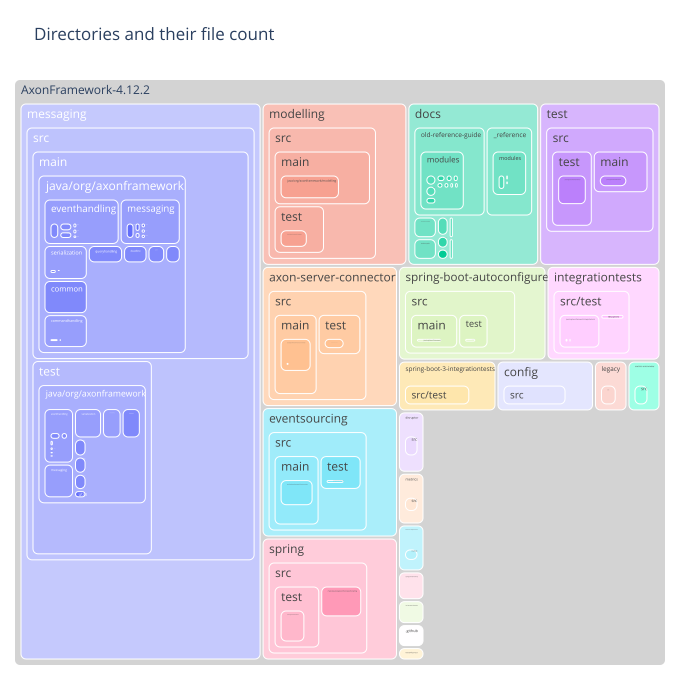

In [24]:
figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    values = git_files_with_commit_statistics['fileCount'],
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Directories and their file count'
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("NumberOfFilesPerDirectory"))

### Most frequent file extension per directory

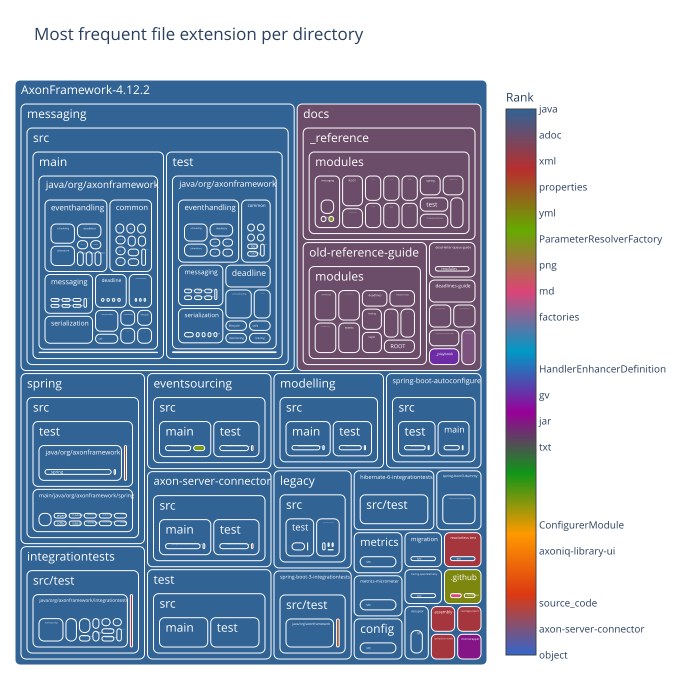

In [25]:
git_files_with_commit_statistics_and_file_extension_rank = pd.merge(
    git_files_with_commit_statistics, 
    git_file_extensions, 
    left_on='mostFrequentFileExtension', 
    right_on="fileExtension",
    how="left",
    validate="m:1"
)
figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_files_with_commit_statistics['fileCount'],
    marker=create_rank_colorbar_for_graph_objects_treemap_marker(git_files_with_commit_statistics_and_file_extension_rank, 'fileExtension', 'fileExtensionCountRank')
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Most frequent file extension per directory'
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("MostFrequentFileExtensionPerDirectory"))

### Number of commits per directory

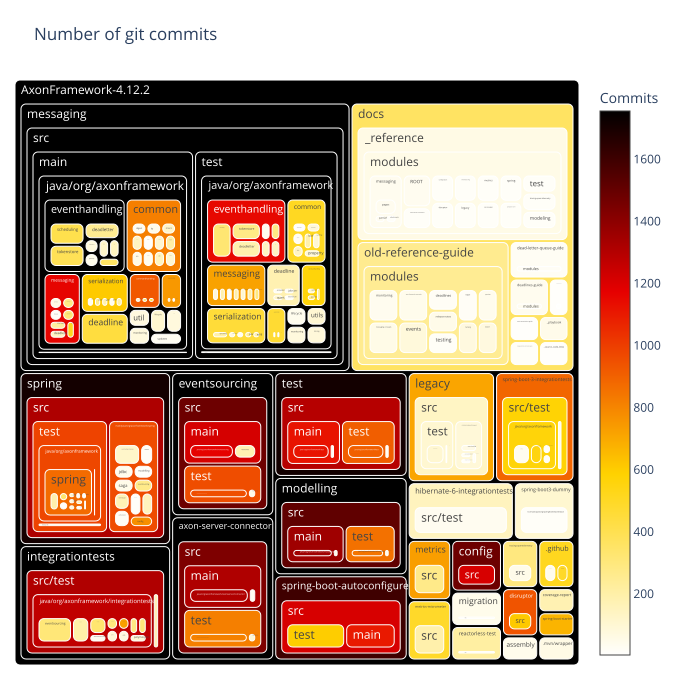

In [26]:
git_commit_count_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "commitCount", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_count_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_count_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_count_per_directory['commitCount_limited'], 
        colorbar=dict(title="Commits"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Number of git commits',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("NumberOfGitCommits"))

### Number of distinct authors per directory

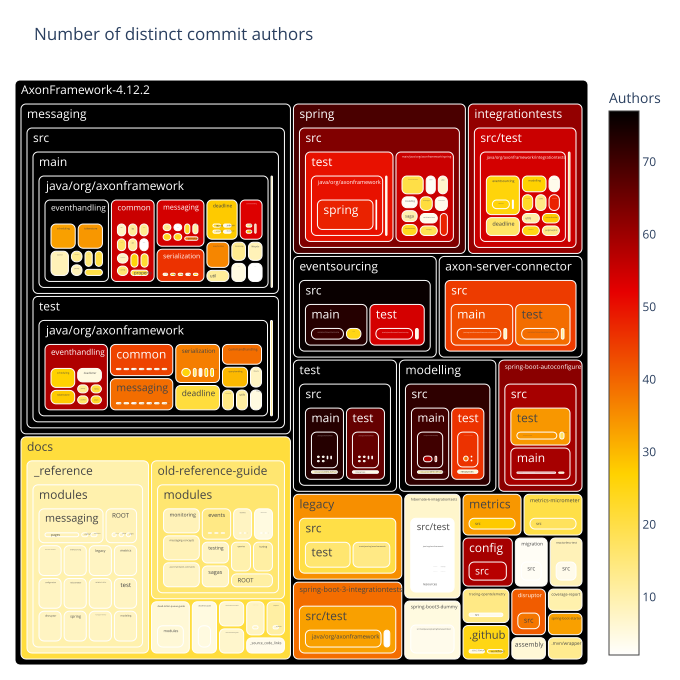

In [27]:
git_commit_authors_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "authorCount", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_authors_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_authors_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_authors_per_directory['authorCount_limited'], 
        colorbar=dict(title="Authors"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Number of distinct commit authors',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("NumberOfDistinctCommitAuthors"))

### Directories with very few different authors

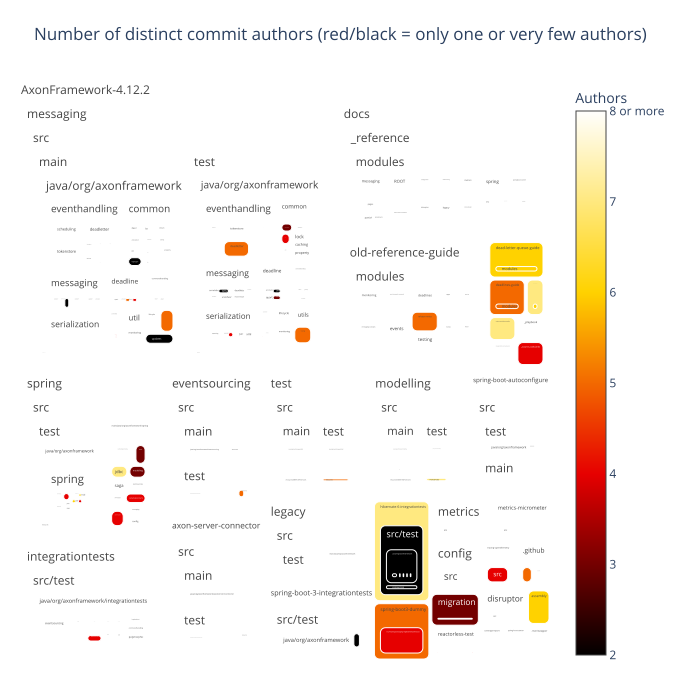

In [28]:
git_commit_authors_per_directory_low_focus = add_quantile_limited_column(git_files_with_commit_statistics, "authorCount", 0.33)

author_count_top_limit = git_commit_authors_per_directory_low_focus['authorCount_limited'].max().astype(int).astype(str)
author_count_top_limit_label_alias = {author_count_top_limit: author_count_top_limit + ' or more'}

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_authors_per_directory_low_focus),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_authors_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_authors_per_directory_low_focus['authorCount_limited'], 
        colorbar=dict(title="Authors",
                      tickmode="auto",
                      labelalias=author_count_top_limit_label_alias
                      ),
        reversescale=True
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Number of distinct commit authors (red/black = only one or very few authors)',
)

figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("NumberOfDistinctCommitAuthorsLowFocus"))

### Main author per directory

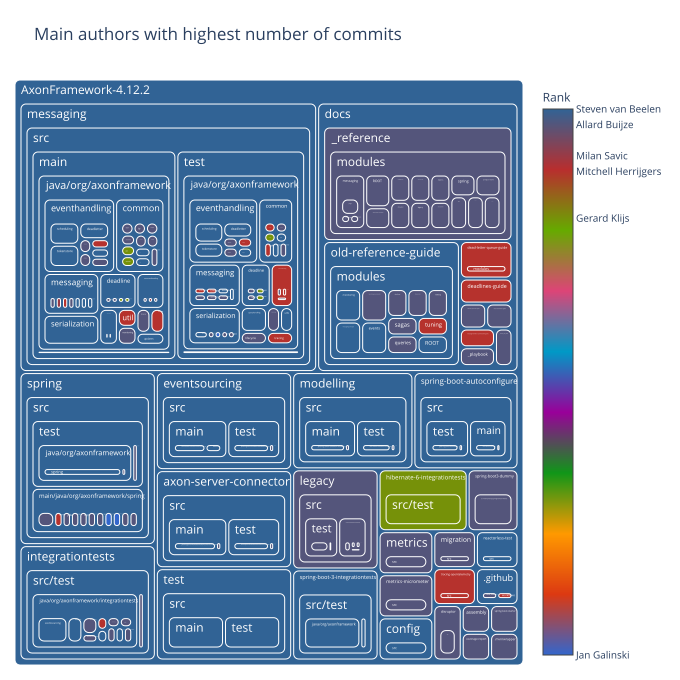

In [29]:
git_files_with_commit_statistics_and_main_author_rank = pd.merge(
    git_files_with_commit_statistics, 
    git_file_authors, 
    left_on='mainAuthor', 
    right_on="author",
    how="left",
    validate="m:1"
)
figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_files_with_commit_statistics['fileCount'],
    marker=create_rank_colorbar_for_graph_objects_treemap_marker(git_files_with_commit_statistics_and_main_author_rank, 'mainAuthor', 'authorCommitCountRank')
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Main authors with highest number of commits'
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("MainAuthorsWithHighestNumberOfCommits"))

### Second author per directory

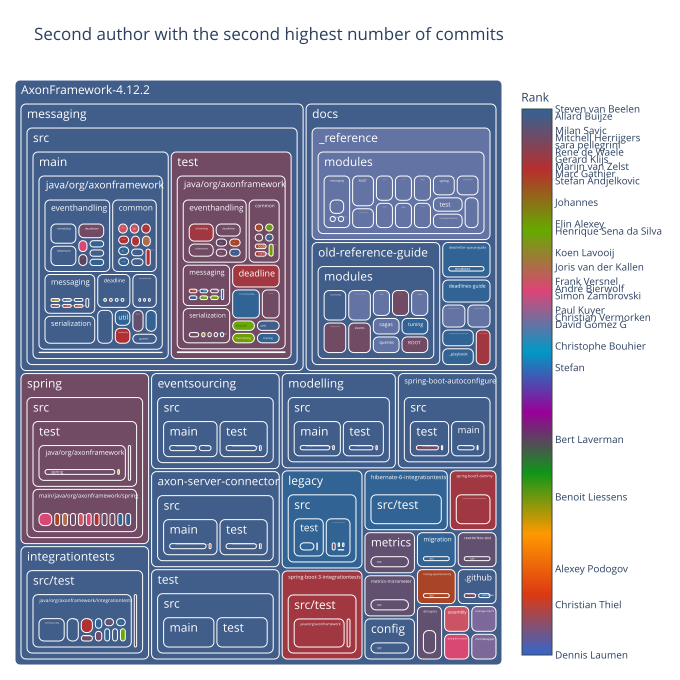

In [30]:
git_files_with_commit_statistics_and_second_author_rank = pd.merge(
    git_files_with_commit_statistics, 
    git_file_authors, 
    left_on='secondAuthor', 
    right_on="author",
    how="left",
    validate="m:1"
)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_files_with_commit_statistics['fileCount'],
    marker=create_rank_colorbar_for_graph_objects_treemap_marker(git_files_with_commit_statistics_and_second_author_rank, 'secondAuthor', 'authorCommitCountRank')
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Second author with the second highest number of commits'
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("SecondAuthorWithTheSecondHighestNumberOfCommits"))

### Days since last commit per directory

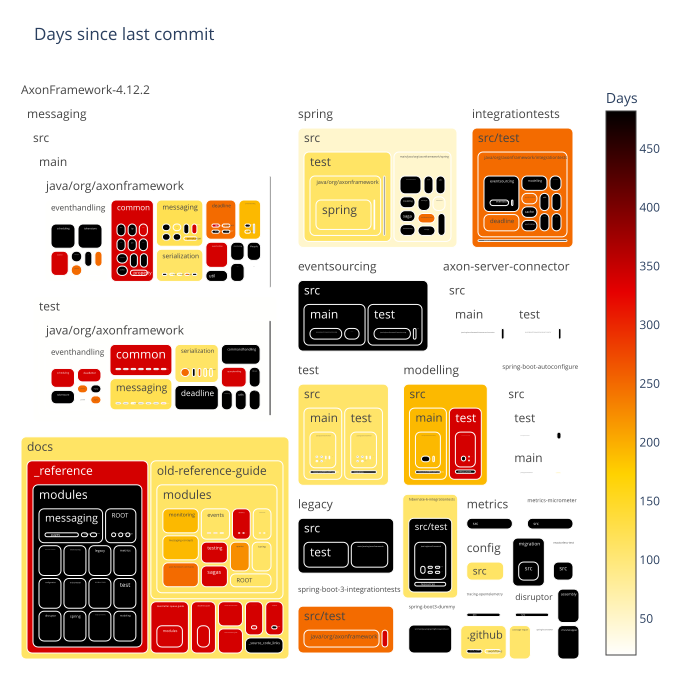

In [31]:
git_commit_days_since_last_commit_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "daysSinceLastCommit", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_commit_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    #values = git_commit_days_since_last_commit_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_commit_per_directory['daysSinceLastCommit_limited'], 
        colorbar=dict(title="Days"),
    ),
))

figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Days since last commit',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("DaysSinceLastCommit"))

### Days since last commit per directory (ranked)

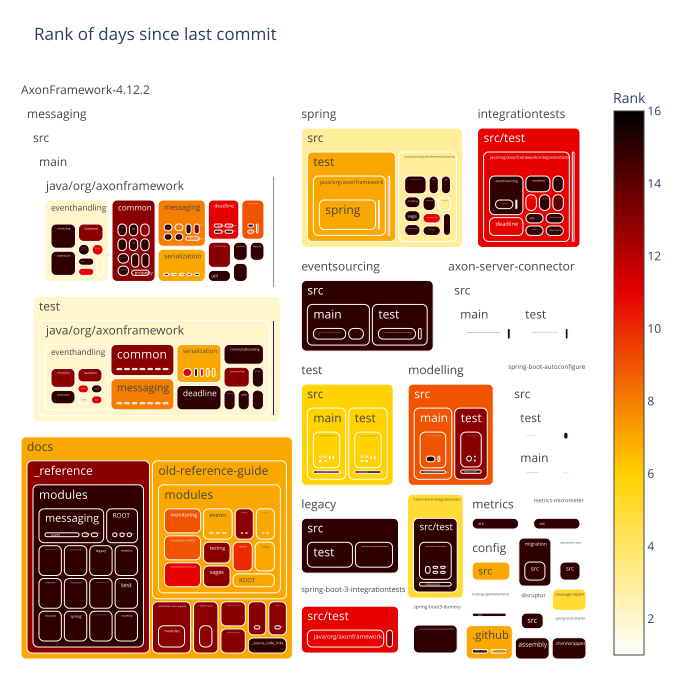

In [32]:
git_commit_days_since_last_commit_per_directory = add_rank_column(git_files_with_commit_statistics, "daysSinceLastCommit")

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_commit_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_commit_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_commit_per_directory['daysSinceLastCommit_rank'], 
        colorbar=dict(title="Rank"),
    ),
))

figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Rank of days since last commit',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("DaysSinceLastCommitRanked"))

### Days since last file creation per directory

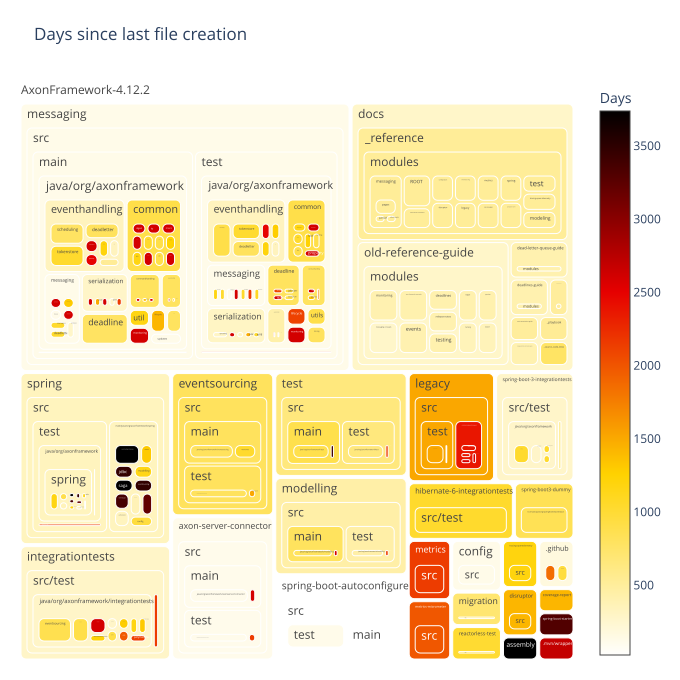

In [33]:
git_commit_days_since_last_file_creation_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "daysSinceLastCreation", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_creation_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_creation_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_creation_per_directory['daysSinceLastCreation_limited'], 
        colorbar=dict(title="Days"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Days since last file creation',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("DaysSinceLastFileCreation"))

### Days since last file creation per directory (ranked)

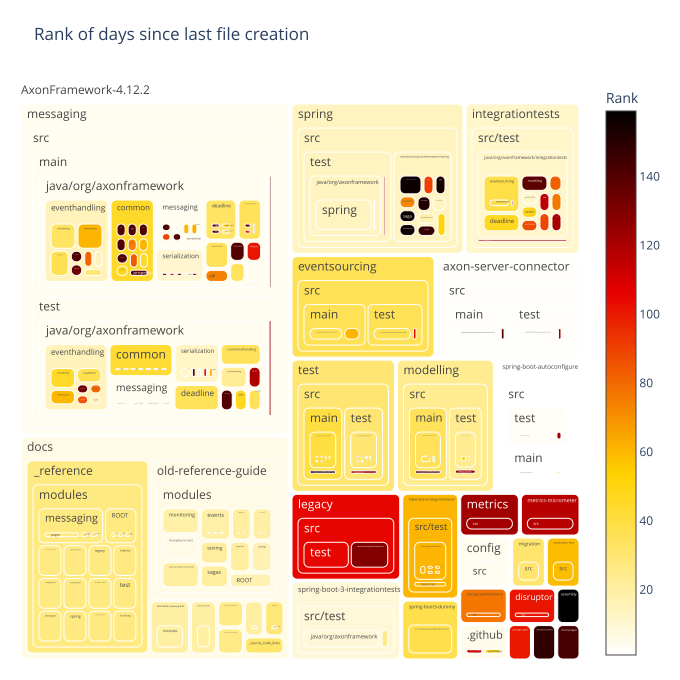

In [34]:
git_commit_days_since_last_file_creation_per_directory = add_rank_column(git_files_with_commit_statistics, "daysSinceLastCreation")

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_creation_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_creation_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_creation_per_directory['daysSinceLastCreation_rank'], 
        colorbar=dict(title="Rank"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Rank of days since last file creation',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("DaysSinceLastFileCreationRanked"))

### Days since last file modification per directory

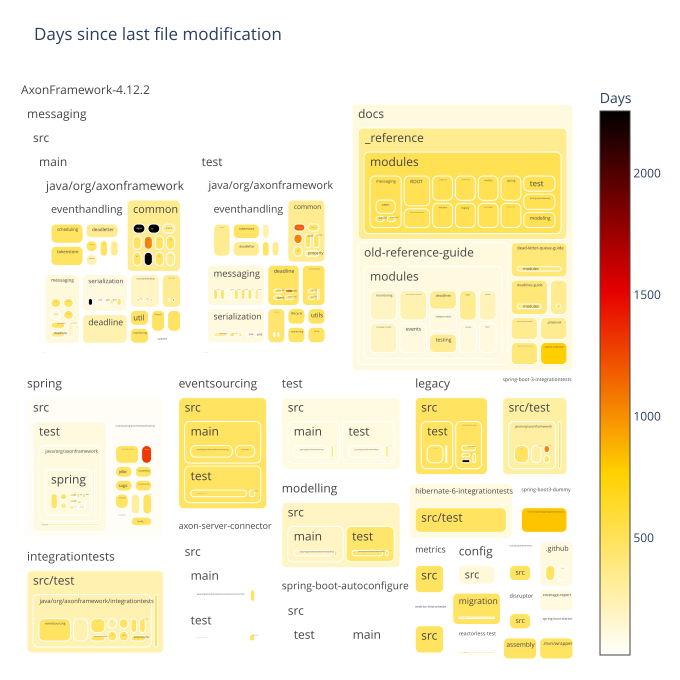

In [35]:
git_commit_days_since_last_file_modification_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "daysSinceLastModification", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_modification_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_modification_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_modification_per_directory['daysSinceLastModification_limited'], 
        colorbar=dict(title="Days"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Days since last file modification',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("DaysSinceLastFileModification"))

### Days since last file modification per directory (ranked)

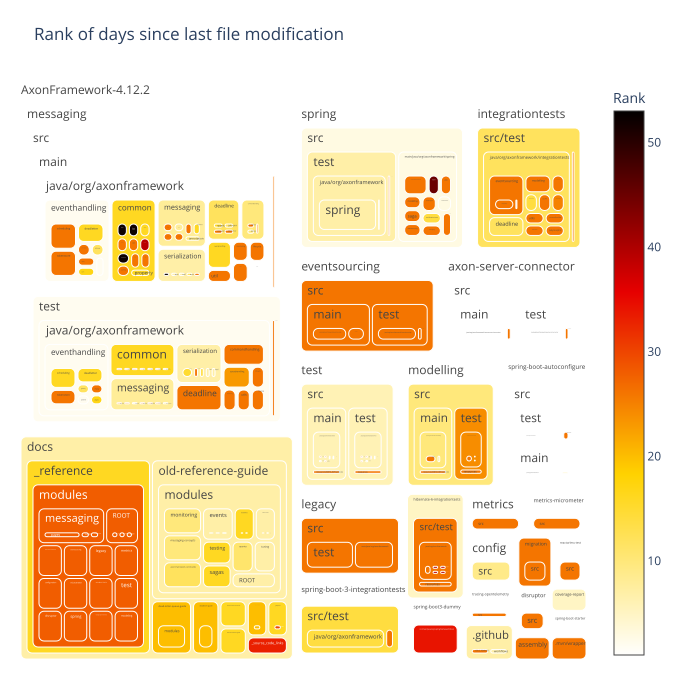

In [36]:
git_commit_days_since_last_file_modification_per_directory = add_rank_column(git_files_with_commit_statistics, "daysSinceLastModification")

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_modification_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_modification_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_modification_per_directory['daysSinceLastModification_rank'], 
        colorbar=dict(title="Rank"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Rank of days since last file modification',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("DaysSinceLastFileModificationRanked"))

## Filecount per commit

Shows how many commits had changed one file, how many had changed two files, and so on.
The chart is limited to 30 lines for improved readability.
The data preview also includes overall statistics including the number of commits that are filtered out in the chart.

### Preview data

In [37]:
git_file_count_per_commit = query_cypher_to_data_frame("../cypher/GitLog/List_git_files_per_commit_distribution.cypher")

print("Sum of commits that changed more than 30 files (each) = " + str(git_file_count_per_commit[git_file_count_per_commit['filesPerCommit'] > 30]['commitCount'].sum()))
print("Max changed files with one commit = " + str(git_file_count_per_commit['filesPerCommit'].max()))
display(git_file_count_per_commit.describe())
display(git_file_count_per_commit.head(30))

Sum of commits that changed more than 30 files (each) = 973
Max changed files with one commit = 2178


,filesPerCommit,commitCount
count,334.000000,334.000000
mean,343.449102,34.667665
std,439.862566,281.534044
min,1.000000,1.000000
25%,84.250000,1.000000
50%,185.000000,2.000000
75%,426.500000,5.000000
max,2178.000000,4625.000000


,filesPerCommit,commitCount
0,1,4625
1,2,1966
2,3,871
3,4,564
4,5,385
5,6,280
6,7,229
7,8,190
8,9,136
9,10,112


### Bar chart with the number of files per commit distribution

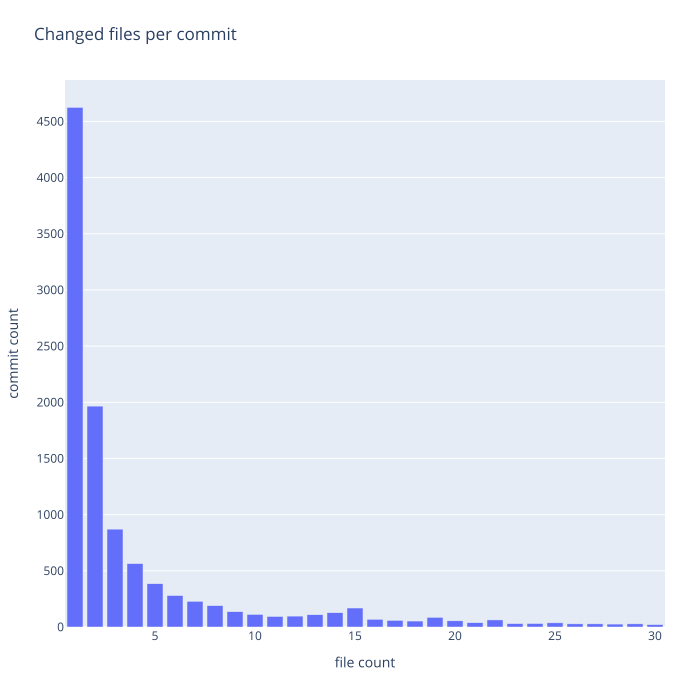

In [38]:
if git_file_count_per_commit.empty:
    print("No data to plot")
else:
    figure = plotly_graph_objects.Figure(plotly_graph_objects.Bar(
        x=git_file_count_per_commit['filesPerCommit'].head(30), 
        y=git_file_count_per_commit['commitCount'].head(30)),
    )
    figure.update_layout(
        **plotly_bar_layout_base_settings,
        title='Changed files per commit',
        xaxis_title='file count',
        yaxis_title='commit count'
    )
    figure.show(**plotly_treemap_figure_show_settings)
    if is_command_line_execution():
        figure.write_image(**get_plotly_figure_write_image_settings("ChangedFilesPerCommit"))

## Pairwise Changed Files

This section analyzes files that where changed together within the same commit and provides several metrics to quantify the strength of the co-change relationship:

- **Commit Count**: The number of commits in which two files were changed together.
- **Commit Lift**: A ratio that indicates whether the co-change pattern is stronger than random chance, given how often each file changes.
- **Jaccard Similarity**: The ratio of commits involving either file that also involved both files.

The following tables show the top pairwise changed files based on these metrics.
The following charts show how these metrics are distributed across pairs of files that were changed together.

### Treemap with files changed frequently with others

In [39]:
data_to_display = query_cypher_to_data_frame("../cypher/GitLog/List_git_files_that_were_changed_together_with_another_file.cypher")

# Debug
# display("1. pairwise changed files --------------")
# display(pairwise_changed_git_files)

# Add multiple rows for each file path containing all its directories paths in the new column 'directoryPath'
data_to_display = add_directory_column(data_to_display, 'filePath', 'directoryPath')

# Debug
# display("2. added directories --------------")
# display(pairwise_changed_git_files)

# Group the git files by their directory and author and count the number of files of each directory (across all levels).
data_to_display = data_to_display.groupby(['directoryPath']).aggregate(
    pairwiseChangeCommitCount=pd.NamedAgg(column="commitCount", aggfunc="sum"),
    pairwiseChangeFileCount=pd.NamedAgg(column="filePath", aggfunc="count"),
    pairwiseChangeAverageRate=pd.NamedAgg(column="coChangeRate", aggfunc="mean"),
    pairwiseChangeMaxLift=pd.NamedAgg(column="maxLift", aggfunc="max"),
    pairwiseChangeAverageLift=pd.NamedAgg(column="avgLift", aggfunc="mean"),
)
data_to_display.reset_index(inplace=True)

# Debug
# display("3. after grouping --------------")
# display(pairwise_changed_git_files)

data_to_display = pd.merge(
    git_files_with_commit_statistics, 
    data_to_display, 
    left_on='directoryPath', 
    right_on="directoryPath",
    how="left",
    validate="m:1"
)

# Debug
# display("4. after merging --------------")
# display(pairwise_changed_git_files)

data_to_display['pairwiseChangeCommitCount'] = data_to_display['pairwiseChangeCommitCount'].fillna(0).astype(int)
data_to_display['pairwiseChangeFileCount'] = data_to_display['pairwiseChangeFileCount'].fillna(0).astype(int)
data_to_display['pairwiseChangeAverageRate'] = data_to_display['pairwiseChangeAverageRate'].fillna(0).astype(float)
data_to_display['pairwiseChangeMaxLift'] = data_to_display['pairwiseChangeMaxLift'].fillna(0).astype(float)
data_to_display['pairwiseChangeAverageLift'] = data_to_display['pairwiseChangeAverageLift'].fillna(0).astype(float)
data_to_display.reset_index(inplace=True)

# Debug
# display("5. after NaN fill --------------")
# display(pairwise_changed_git_files)

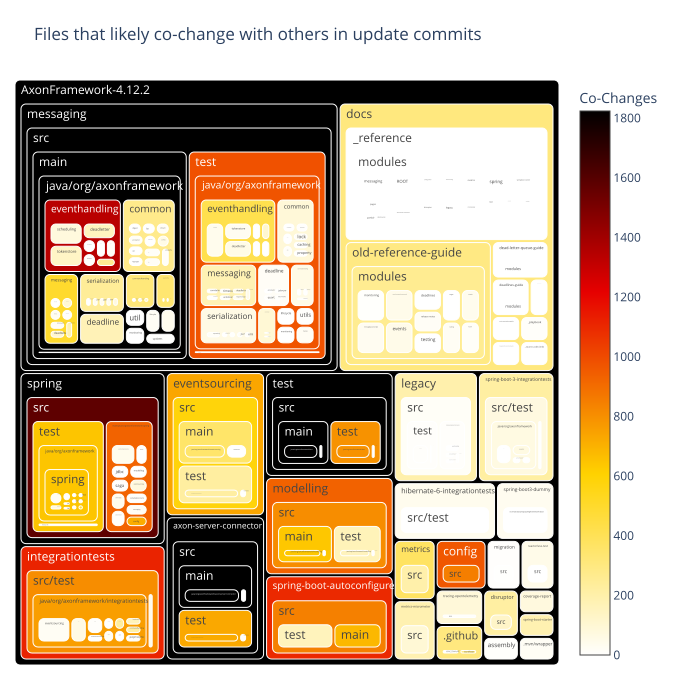

In [40]:
data_to_display = add_quantile_limited_column(data_to_display, "pairwiseChangeCommitCount", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(data_to_display),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = pairwise_changed_git_files['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=data_to_display['pairwiseChangeCommitCount_limited'], 
        colorbar=dict(title="Co-Changes"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Files that likely co-change with others in update commits',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("CoChangingFiles"))

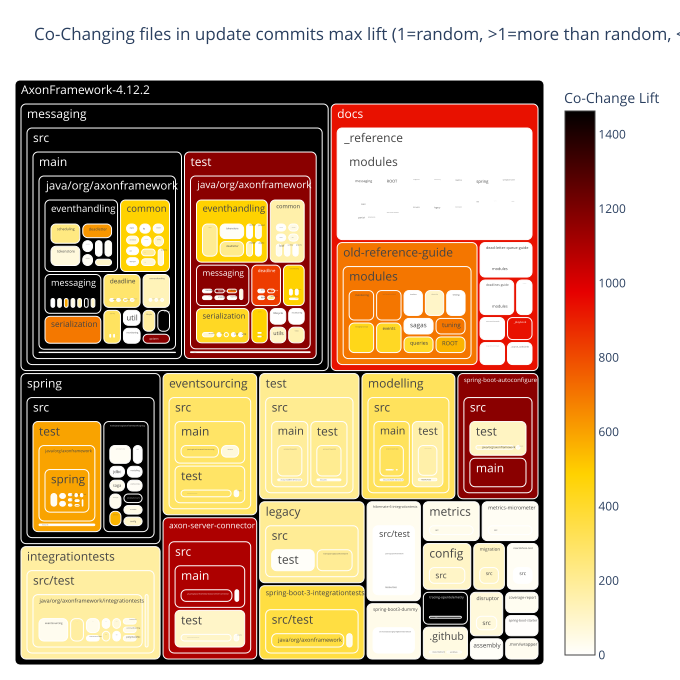

In [41]:
data_to_display = add_quantile_limited_column(data_to_display, "pairwiseChangeMaxLift", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(data_to_display),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = pairwise_changed_git_files['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=data_to_display['pairwiseChangeMaxLift_limited'], 
        colorbar=dict(title="Co-Change Lift"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Co-Changing files in update commits max lift (1=random, >1=more than random, <1=less than random)',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("CoChangingFilesMaxLift"))

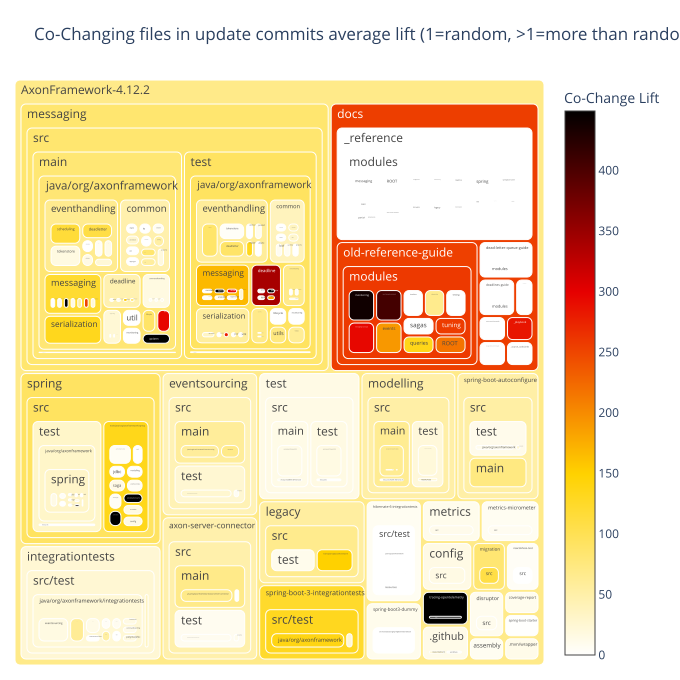

In [42]:
data_to_display = add_quantile_limited_column(data_to_display, "pairwiseChangeAverageLift", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(data_to_display),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = pairwise_changed_git_files['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=data_to_display['pairwiseChangeAverageLift_limited'], 
        colorbar=dict(title="Co-Change Lift"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Co-Changing files in update commits average lift (1=random, >1=more than random, <1=less than random)',
)
figure.show(**plotly_treemap_figure_show_settings)
if is_command_line_execution():
    figure.write_image(**get_plotly_figure_write_image_settings("CoChangingFilesAverageLift"))

In [43]:
# Initial steps: Function Declaration and Data Preparation for co-change distribution analysis

In [44]:
pairwise_changed_git_files = query_cypher_to_data_frame("../cypher/GitLog/List_pairwise_changed_files.cypher")

In [45]:
def find_top_pairwise_changed_file_extensions(input_data: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Finds the top N pairwise changed file extensions based on commit count.
    input_data : pd.DataFrame : DataFrame containing pairwise changed files with their pair counts and extensions
    top_n : int : The number of top extensions to return
    return : pd.Series : Series with top N file extension pairs sorted by their pair count descending
    """
    top_extensions = input_data.groupby('fileExtensionPair', observed=False).aggregate(
        fileExtensionPairCount=pd.NamedAgg(column="filePairWithRelativePath", aggfunc="count")
    ).reset_index()
    
    return top_extensions.sort_values(by='fileExtensionPairCount', ascending=False).reset_index(drop=True).head(top_n)

In [46]:
top_pairwise_changed_file_extensions = find_top_pairwise_changed_file_extensions(pairwise_changed_git_files, top_n=4)
display(top_pairwise_changed_file_extensions)

pairwise_changed_git_files = pairwise_changed_git_files.merge(top_pairwise_changed_file_extensions, on='fileExtensionPair')

top_pairwise_changed_file_extensions = top_pairwise_changed_file_extensions['fileExtensionPair']
pairwise_changed_git_files = pairwise_changed_git_files[pairwise_changed_git_files['fileExtensionPair'].isin(top_pairwise_changed_file_extensions)]

,fileExtensionPair,fileExtensionPairCount
0,java↔java,15199
1,java↔xml,2643
2,java↔yml,408
3,adoc↔xml,221


In [47]:
def add_file_extension_rank_column(data_frame: pd.DataFrame, column_name: str):
    """
    Adds a 'fileExtensionPair' based rank column to the DataFrame for the value of the specified column.
    data_frame : pd.DataFrame : The input DataFrame
    column_name : str : The name of the column to rank
    return : pd.DataFrame : The DataFrame with added rank column
    """
    if column_name + '_rank' in data_frame.columns:
        return data_frame # Column already exists
    
    # Create a new rank column based on the specified column and group by the group column
    data_frame[f"{column_name}ExtensionRank"] = data_frame.groupby('fileExtensionPair', observed=False)[column_name].rank(ascending=False, method='dense').astype(int)
    return data_frame

In [48]:
pairwise_changed_git_files = add_file_extension_rank_column(pairwise_changed_git_files, "updateCommitCount")
pairwise_changed_git_files = add_file_extension_rank_column(pairwise_changed_git_files, "updateCommitMinConfidence")
pairwise_changed_git_files = add_file_extension_rank_column(pairwise_changed_git_files, "updateCommitJaccardSimilarity")
pairwise_changed_git_files = add_file_extension_rank_column(pairwise_changed_git_files, "updateCommitLift")

In [49]:
def display_table_for_top_pairwise_changed_file_extensions(
        data_to_display: pd.DataFrame, 
        metric_column: str,
        top_n: int = 10
    ):
    """
    Displays a table containing the top N ranked pairwise changed file extensions based on the specified metric column.
    data_to_plot : pd.DataFrame : DataFrame containing pairwise changed files with their commit counts
    metric_column : str : The column to sort the data by
    top_n : int : The number of top entries to display for each extension (default is 10)
    """
    filtered_data = data_to_display[data_to_display[metric_column + "ExtensionRank"] <= top_n]
    
    # Group by the file extensions and the metric and its rank.
    # Since some entries might have the same metric value, we aggregate by the first file pair with relative path and the first file pair.
    # This way we can pick the top n entries for each file extension pair.
    grouping_columns = ["fileExtensionPairCount", "fileExtensionPair", metric_column,  metric_column + "ExtensionRank"]
    grouped_data = filtered_data.groupby(grouping_columns).aggregate(
        filePair=pd.NamedAgg(column="filePair", aggfunc="first"),
        filePairWithRelativePath=pd.NamedAgg(column="filePairWithRelativePath", aggfunc="first"),
    ).reset_index()
    
    return (grouped_data
            .sort_values(by=grouping_columns, ascending=[False, True, False, True])
            .reset_index(drop=True)
            .rename(columns={metric_column + "ExtensionRank": "GroupRank"})
            .drop(columns=['fileExtensionPairCount'])
        )

In [50]:
def plot_histogram_of_pairwise_changed_files(
        data_to_plot: pd.DataFrame,
        top_pairwise_changed_file_extensions: pd.Series,
        x_axis_column: str = "updateCommitCount",
        x_axis_label: str = "Commit Count",
        output_file_name: str = "CoChangedFilesByCommitCount",
        sub_plot_rows: int = 4, 
        sub_plot_columns: int = 1,
    ):
    """
    Plots a histogram of pairwise changed files based on their commit count.
    pairwise_changed_git_files : pd.DataFrame : DataFrame containing pairwise changed files with their commit counts
    top_extensions_number : int : The number of top extensions to plot
    """

    if data_to_plot.empty:
        print("No data to plot")
        return
    
    if top_pairwise_changed_file_extensions.size != sub_plot_rows * sub_plot_columns:
        raise ValueError(f"Number of top pairwise changed file extensions ({top_pairwise_changed_file_extensions.size}) does not match the number of subplots ({sub_plot_rows * sub_plot_columns}).")

    figure = make_subplots(
        rows=sub_plot_rows, 
        cols=sub_plot_columns, 
        subplot_titles=top_pairwise_changed_file_extensions,
        vertical_spacing=0.06,   
        horizontal_spacing=0.04
    )

    # Add one subplot per extension pair
    for index, extension in enumerate(top_pairwise_changed_file_extensions, start=1):
        row = (index - 1) // sub_plot_columns + 1
        column = (index - 1) % sub_plot_columns + 1

        data_for_subplot = data_to_plot[data_to_plot["fileExtensionPair"] == extension]

        figure.add_trace(
            plotly_graph_objects.Histogram(
                x=data_for_subplot[x_axis_column],
                text=data_for_subplot["filePairLineBreak"],
                textposition="inside",
                hovertext=data_for_subplot["filePairWithRelativePath"],
                nbinsx=40,
                textfont=dict(size=12, color="white"),
                name=extension,
            ),
            row=row,
            col=column
        )
        # Make subplot title larger
        figure.layout.annotations[index - 1].update(font=dict(size=18))
        # Label subplot x axis 
        figure.update_xaxes(title_text=x_axis_label, row=row, col=column)
        # Label subplot y axis and make it logarithmic
        figure.update_yaxes(title_text="File Pair Count (log)", type="log", row=row, col=column)

    figure.update_layout(
        margin=dict(t=100, l=10, r=10, b=10),
        title="Co-Changed Files by their " + x_axis_label.lower(),
        title_font_size=20,
        title_y=0.99,
        bargap=0.05,
        height=2000,
        width=1000,
        showlegend=False
    )

    figure.show(**plotly_treemap_figure_show_settings)
    if is_command_line_execution():
        figure.write_image(**get_plotly_figure_write_image_settings(output_file_name))

### Files changed together by commit count

In [51]:
display_table_for_top_pairwise_changed_file_extensions(
    pairwise_changed_git_files,
    "updateCommitCount",
)

,fileExtensionPair,updateCommitCount,GroupRank,filePair,filePairWithRelativePath
0,java↔java,163,1,AxonServerCommandBus↔AxonServerQueryBus,axon-server-connector/src/main/java/org/axonframework/axonserver/connector/command/AxonServerCommandBus.java↔axon-server-connector/src/main/java/org/axonframework/axonserver/connector/query/AxonServerQueryBus.java
1,java↔java,144,2,AxonServerQueryBus↔AxonServerQueryBusTest,axon-server-connector/src/main/java/org/axonframework/axonserver/connector/query/AxonServerQueryBus.java↔axon-server-connector/src/test/java/org/axonframework/axonserver/connector/query/AxonServerQueryBusTest.java
2,java↔java,135,3,SpringAxonAutoConfigurerTest↔SpringAxonAutoConfigurer,spring/src/test/java/org/axonframework/spring/config/SpringAxonAutoConfigurerTest.java↔spring/src/main/java/org/axonframework/spring/config/SpringAxonAutoConfigurer.java
3,java↔java,121,4,TrackingEventProcessorTest↔TrackingEventProcessor,integrationtests/src/test/java/org/axonframework/integrationtests/eventhandling/TrackingEventProcessorTest.java↔messaging/src/main/java/org/axonframework/eventhandling/TrackingEventProcessor.java
4,java↔java,107,5,SpringAxonAutoConfigurer↔AxonConfiguration,spring/src/main/java/org/axonframework/spring/config/SpringAxonAutoConfigurer.java↔spring/src/main/java/org/axonframework/spring/config/AxonConfiguration.java
5,java↔java,101,6,AxonServerCommandBus↔AxonServerCommandBusTest,axon-server-connector/src/main/java/org/axonframework/axonserver/connector/command/AxonServerCommandBus.java↔axon-server-connector/src/test/java/org/axonframework/axonserver/connector/command/AxonServerCommandBusTest.java
6,java↔java,100,7,EventProcessingModule↔EventProcessingModuleTest,config/src/main/java/org/axonframework/config/EventProcessingModule.java↔config/src/test/java/org/axonframework/config/EventProcessingModuleTest.java
7,java↔java,96,8,SagaTestFixture↔AggregateTestFixture,test/src/main/java/org/axonframework/test/saga/SagaTestFixture.java↔test/src/main/java/org/axonframework/test/aggregate/AggregateTestFixture.java
8,java↔java,95,9,AxonServerCommandBusTest↔AxonServerQueryBusTest,axon-server-connector/src/test/java/org/axonframework/axonserver/connector/command/AxonServerCommandBusTest.java↔axon-server-connector/src/test/java/org/axonframework/axonserver/connector/query/AxonServerQueryBusTest.java
9,java↔java,94,10,AggregateTestFixture↔FixtureConfiguration,test/src/main/java/org/axonframework/test/aggregate/AggregateTestFixture.java↔test/src/main/java/org/axonframework/test/aggregate/FixtureConfiguration.java


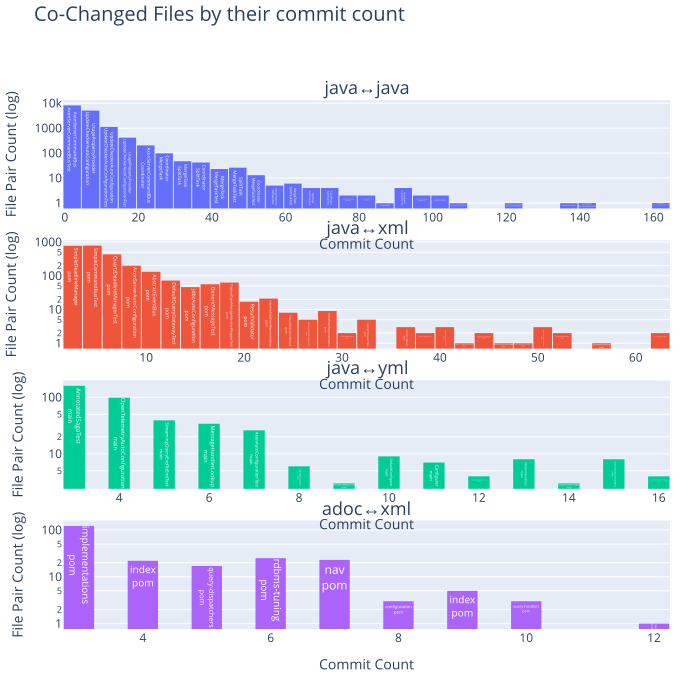

In [52]:
plot_histogram_of_pairwise_changed_files(
    data_to_plot = pairwise_changed_git_files,
    top_pairwise_changed_file_extensions = top_pairwise_changed_file_extensions,
    x_axis_column = "updateCommitCount",
    x_axis_label = "Commit Count",
    output_file_name = "CoChangedFilesByCommitCount"
)

### Files changed together by commit min confidence

The commit min confidence is the commit count where both files were changed divided by the commit count of the file with the least commits.
This metric is useful to identify pairs of files that are frequently changed together and is not biased by single files that are changed very often.

In [53]:
display_table_for_top_pairwise_changed_file_extensions(
    pairwise_changed_git_files,
    "updateCommitMinConfidence"
)

,fileExtensionPair,updateCommitMinConfidence,GroupRank,filePair,filePairWithRelativePath
0,java↔java,1.000000,1,UsagePropertyProvider↔UpdateCheckerAutoConfiguration,messaging/src/main/java/org/axonframework/updates/configuration/UsagePropertyProvider.java↔spring-boot-autoconfigure/src/main/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfiguration.java
1,java↔java,0.909091,2,AvroUtil↔SpecificRecordBaseSerializerStrategy,messaging/src/main/java/org/axonframework/serialization/avro/AvroUtil.java↔messaging/src/main/java/org/axonframework/serialization/avro/SpecificRecordBaseSerializerStrategy.java
2,java↔java,0.900000,3,UnitOfWorkTimeoutInterceptor↔TimeoutWrappedMessageHandlingMember,messaging/src/main/java/org/axonframework/messaging/timeout/UnitOfWorkTimeoutInterceptor.java↔messaging/src/main/java/org/axonframework/messaging/timeout/TimeoutWrappedMessageHandlingMember.java
3,java↔java,0.875000,4,Decisions↔DoNotEnqueue,messaging/src/main/java/org/axonframework/messaging/deadletter/Decisions.java↔messaging/src/main/java/org/axonframework/messaging/deadletter/DoNotEnqueue.java
4,java↔java,0.857143,5,AvroSerializer↔AvroSerializerStrategy,messaging/src/main/java/org/axonframework/serialization/avro/AvroSerializer.java↔messaging/src/main/java/org/axonframework/serialization/avro/AvroSerializerStrategy.java
5,java↔java,0.833333,6,AvroSerializerStrategy↔ByteArrayToGenericRecordConverter,messaging/src/main/java/org/axonframework/serialization/avro/AvroSerializerStrategy.java↔messaging/src/main/java/org/axonframework/serialization/avro/ByteArrayToGenericRecordConverter.java
6,java↔java,0.800000,7,DeadLetteringEventIntegrationTest↔InMemoryDeadLetteringIntegrationTest,messaging/src/test/java/org/axonframework/eventhandling/deadletter/DeadLetteringEventIntegrationTest.java↔messaging/src/test/java/org/axonframework/eventhandling/deadletter/InMemoryDeadLetteringIntegrationTest.java
7,java↔java,0.785714,8,AvroSerializer↔AvroSerializerTest,messaging/src/main/java/org/axonframework/serialization/avro/AvroSerializer.java↔messaging/src/test/java/org/axonframework/serialization/avro/AvroSerializerTest.java
8,java↔java,0.777778,9,JobrunrDeadlineManagerTest↔JobRunrEventSchedulerTest,integrationtests/src/test/java/org/axonframework/integrationtests/deadline/jobrunr/JobrunrDeadlineManagerTest.java↔messaging/src/test/java/org/axonframework/eventhandling/scheduling/jobrunr/JobRunrEventSchedulerTest.java
9,java↔java,0.750000,10,AxonServerAutoConfiguration↔PersistentStreamMessageSource,spring-boot-autoconfigure/src/main/java/org/axonframework/springboot/autoconfig/AxonServerAutoConfiguration.java↔axon-server-connector/src/main/java/org/axonframework/axonserver/connector/event/axon/PersistentStreamMessageSource.java


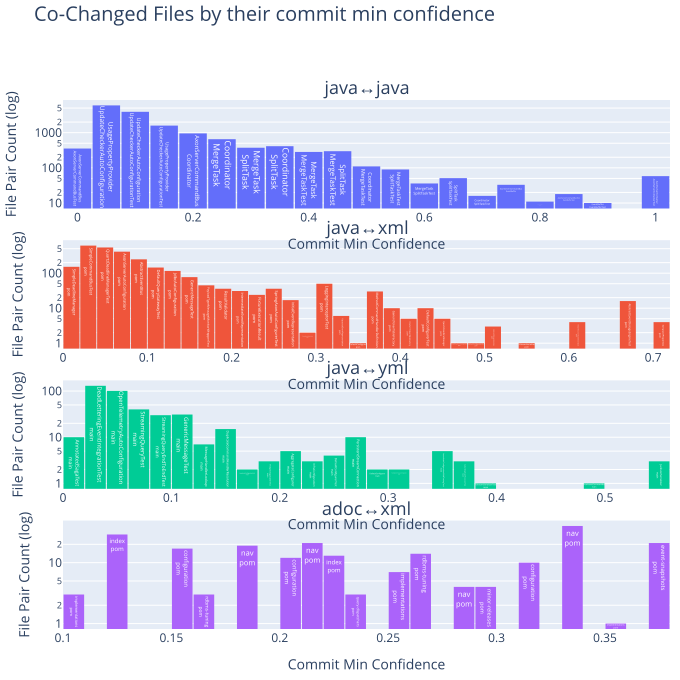

In [54]:
plot_histogram_of_pairwise_changed_files(
    data_to_plot = pairwise_changed_git_files,
    top_pairwise_changed_file_extensions = top_pairwise_changed_file_extensions,
    x_axis_column = "updateCommitMinConfidence",
    x_axis_label = "Commit Min Confidence",
    output_file_name = "CoChangedFilesByCommitMinConfidence"
)

### Files changed together by commit lift

In [55]:
display_table_for_top_pairwise_changed_file_extensions(
    pairwise_changed_git_files,
    "updateCommitLift"
)

,fileExtensionPair,updateCommitLift,GroupRank,filePair,filePairWithRelativePath
0,java↔java,1950.333333,1,AvroSchemaPackages↔AvroSchemaScan,spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaPackages.java↔spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaScan.java
1,java↔java,1462.750000,2,DefaultEventProcessorSpanFactory↔DefaultEventProcessorSpanFactoryTest,messaging/src/main/java/org/axonframework/eventhandling/DefaultEventProcessorSpanFactory.java↔messaging/src/test/java/org/axonframework/eventhandling/DefaultEventProcessorSpanFactoryTest.java
2,java↔java,1170.200000,3,UsagePropertyProvider↔UpdateCheckerAutoConfiguration,messaging/src/main/java/org/axonframework/updates/configuration/UsagePropertyProvider.java↔spring-boot-autoconfigure/src/main/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfiguration.java
3,java↔java,1097.062500,4,AxonServerEventStoreFactory↔AxonServerEventStoreFactoryTest,axon-server-connector/src/main/java/org/axonframework/axonserver/connector/event/axon/AxonServerEventStoreFactory.java↔axon-server-connector/src/test/java/org/axonframework/axonserver/connector/event/axon/AxonServerEventStoreFactoryTest.java
4,java↔java,975.166667,5,AvroSchemaPackages↔SpecificRecordBaseClasspathAvroSchemaLoader,spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaPackages.java↔spring/src/main/java/org/axonframework/spring/serialization/avro/SpecificRecordBaseClasspathAvroSchemaLoader.java
5,java↔java,835.857143,6,DeadlineDetailsSerializationTest↔JobRunrDeadlineManagerBuilderTest,messaging/src/test/java/org/axonframework/deadline/jobrunr/DeadlineDetailsSerializationTest.java↔messaging/src/test/java/org/axonframework/deadline/jobrunr/JobRunrDeadlineManagerBuilderTest.java
6,java↔java,731.375000,7,EnqueuePolicy↔NoSuchDeadLetterException,messaging/src/main/java/org/axonframework/messaging/deadletter/EnqueuePolicy.java↔messaging/src/main/java/org/axonframework/messaging/deadletter/NoSuchDeadLetterException.java
7,java↔java,702.120000,8,AxonServerNonTransientRemoteCommandHandlingException↔AxonServerNonTransientRemoteQueryHandlingException,axon-server-connector/src/main/java/org/axonframework/axonserver/connector/command/AxonServerNonTransientRemoteCommandHandlingException.java↔axon-server-connector/src/main/java/org/axonframework/axonserver/connector/query/AxonServerNonTransientRemoteQueryHandlingException.java
8,java↔java,696.547619,9,AvroSerializerStrategy↔ByteArrayToGenericRecordConverter,messaging/src/main/java/org/axonframework/serialization/avro/AvroSerializerStrategy.java↔messaging/src/main/java/org/axonframework/serialization/avro/ByteArrayToGenericRecordConverter.java
9,java↔java,650.111111,10,ShouldEnqueue↔IgnoreTest,messaging/src/main/java/org/axonframework/messaging/deadletter/ShouldEnqueue.java↔messaging/src/test/java/org/axonframework/messaging/deadletter/IgnoreTest.java


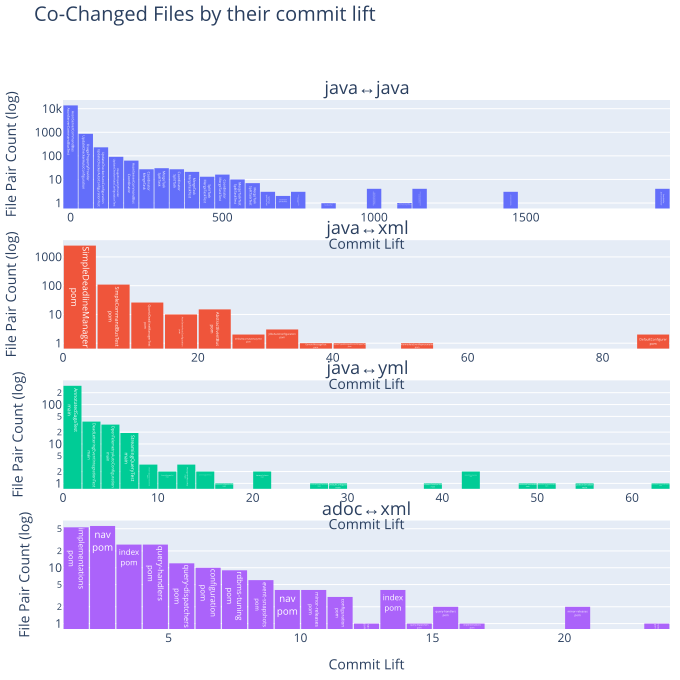

In [56]:
plot_histogram_of_pairwise_changed_files(
    data_to_plot = pairwise_changed_git_files,
    top_pairwise_changed_file_extensions = top_pairwise_changed_file_extensions,
    x_axis_column = "updateCommitLift",
    x_axis_label = "Commit Lift",
    output_file_name = "CoChangedFilesByCommitLift"
)

### Files changed together by commit Jaccard similarity

In [57]:
display_table_for_top_pairwise_changed_file_extensions(
    pairwise_changed_git_files,
    "updateCommitJaccardSimilarity"
)

,fileExtensionPair,updateCommitJaccardSimilarity,GroupRank,filePair,filePairWithRelativePath
0,java↔java,1.000000,1,UsagePropertyProvider↔UpdateCheckerAutoConfiguration,messaging/src/main/java/org/axonframework/updates/configuration/UsagePropertyProvider.java↔spring-boot-autoconfigure/src/main/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfiguration.java
1,java↔java,0.800000,2,DoNotEnqueueTest↔ShouldEnqueueTest,messaging/src/test/java/org/axonframework/messaging/deadletter/DoNotEnqueueTest.java↔messaging/src/test/java/org/axonframework/messaging/deadletter/ShouldEnqueueTest.java
2,java↔java,0.750000,3,DefaultEventProcessorSpanFactory↔DefaultEventProcessorSpanFactoryTest,messaging/src/main/java/org/axonframework/eventhandling/DefaultEventProcessorSpanFactory.java↔messaging/src/test/java/org/axonframework/eventhandling/DefaultEventProcessorSpanFactoryTest.java
3,java↔java,0.714286,4,AvroUtil↔SpecificRecordBaseSerializerStrategy,messaging/src/main/java/org/axonframework/serialization/avro/AvroUtil.java↔messaging/src/main/java/org/axonframework/serialization/avro/SpecificRecordBaseSerializerStrategy.java
4,java↔java,0.700000,5,DoNotEnqueue↔ShouldEnqueue,messaging/src/main/java/org/axonframework/messaging/deadletter/DoNotEnqueue.java↔messaging/src/main/java/org/axonframework/messaging/deadletter/ShouldEnqueue.java
5,java↔java,0.625000,6,AvroSerializerStrategy↔ByteArrayToGenericRecordConverter,messaging/src/main/java/org/axonframework/serialization/avro/AvroSerializerStrategy.java↔messaging/src/main/java/org/axonframework/serialization/avro/ByteArrayToGenericRecordConverter.java
6,java↔java,0.600000,7,UnitOfWorkTimeoutInterceptor↔TimeoutWrappedMessageHandlingMember,messaging/src/main/java/org/axonframework/messaging/timeout/UnitOfWorkTimeoutInterceptor.java↔messaging/src/main/java/org/axonframework/messaging/timeout/TimeoutWrappedMessageHandlingMember.java
7,java↔java,0.555556,8,MessageAuthorizationDispatchInterceptorTest↔MessageAuthorizationHandlerInterceptorTest,spring/src/test/java/org/axonframework/spring/authorization/MessageAuthorizationDispatchInterceptorTest.java↔spring/src/test/java/org/axonframework/spring/authorization/MessageAuthorizationHandlerInterceptorTest.java
8,java↔java,0.545455,9,ShouldEnqueue↔DoNotEnqueueTest,messaging/src/main/java/org/axonframework/messaging/deadletter/ShouldEnqueue.java↔messaging/src/test/java/org/axonframework/messaging/deadletter/DoNotEnqueueTest.java
9,java↔java,0.529412,10,AnnotatedChildEntity↔ChildEntity,modelling/src/main/java/org/axonframework/modelling/command/inspection/AnnotatedChildEntity.java↔modelling/src/main/java/org/axonframework/modelling/command/inspection/ChildEntity.java


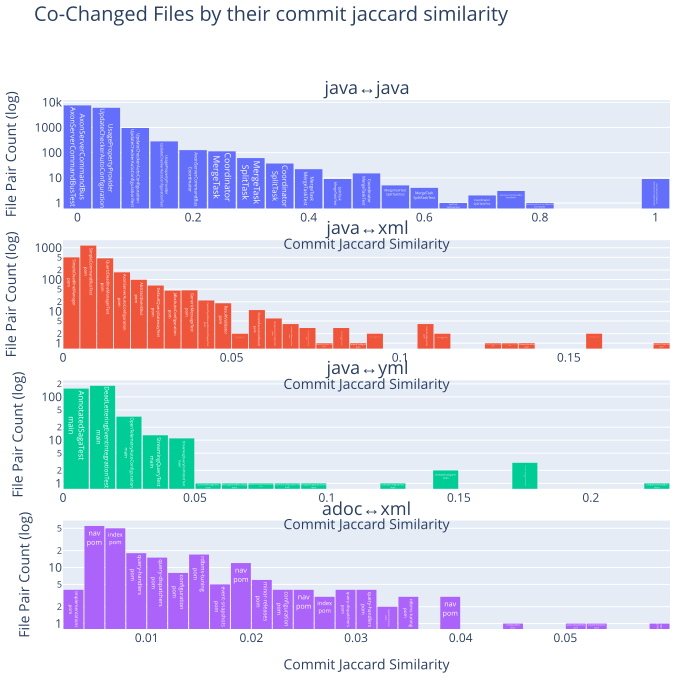

In [58]:
plot_histogram_of_pairwise_changed_files(
    data_to_plot = pairwise_changed_git_files,
    top_pairwise_changed_file_extensions = top_pairwise_changed_file_extensions,
    x_axis_column = "updateCommitJaccardSimilarity",
    x_axis_label = "Commit Jaccard Similarity",
    output_file_name = "CoChangedFilesByCommitJaccardSimilarity"
)

### Find pairwise changed files with many highly ranked metrics

Find those pairwise changed files that have a high rank in many metrics by calculating a combined (weighted) score based on the ranks of each metric.
This is useful to identify pairs of files that score high in most metrics, which indicates a strong co-change relationship.

In [59]:
metric_rank_columns = [
    'updateCommitCountExtensionRank',
    'updateCommitMinConfidenceExtensionRank',
    'updateCommitJaccardSimilarityExtensionRank',
    'updateCommitLiftExtensionRank'
]

metric_columns = [
    'updateCommitCount',
    'updateCommitMinConfidence',
    'updateCommitJaccardSimilarity',
    'updateCommitLift'
]

In [60]:
pairwise_changed_git_files['combinedMetricsScore'] = (
    pairwise_changed_git_files['updateCommitCountExtensionRank'] +
    pairwise_changed_git_files['updateCommitMinConfidenceExtensionRank'] +
    pairwise_changed_git_files['updateCommitJaccardSimilarityExtensionRank'] +
    pairwise_changed_git_files['updateCommitLiftExtensionRank']
)

columns_to_show = ["fileExtensionPair", "filePair", "combinedMetricsScore"] + metric_rank_columns + metric_columns + ["filePairWithRelativePath"]

pairwise_changed_git_files_top_10_ranks = pairwise_changed_git_files.\
    sort_values(by=["fileExtensionPair", "combinedMetricsScore"], ascending=[True, True]).\
    groupby("fileExtensionPair").\
    head(10).\
    reset_index(drop=True)\
    [columns_to_show]

display(pairwise_changed_git_files_top_10_ranks)

,fileExtensionPair,filePair,combinedMetricsScore,updateCommitCountExtensionRank,updateCommitMinConfidenceExtensionRank,updateCommitJaccardSimilarityExtensionRank,updateCommitLiftExtensionRank,updateCommitCount,updateCommitMinConfidence,updateCommitJaccardSimilarity,updateCommitLift,filePairWithRelativePath
0,adoc↔xml,index↔pom,24,9,1,13,1,3,0.375000,0.030612,23.592742,docs/old-reference-guide/modules/queries/pages/index.adoc↔spring-boot3-dummy/pom.xml
1,adoc↔xml,nav↔pom,27,6,13,2,6,6,0.222222,0.052632,13.980884,docs/old-reference-guide/modules/nav.adoc↔spring-boot3-dummy/pom.xml
2,adoc↔xml,configuration↔pom,28,9,3,14,2,3,0.333333,0.030303,20.971326,docs/old-reference-guide/modules/queries/pages/configuration.adoc↔spring-boot3-dummy/pom.xml
3,adoc↔xml,nav↔pom,28,9,3,14,2,3,0.333333,0.030303,20.971326,docs/old-reference-guide/modules/queries/partials/nav.adoc↔spring-boot3-dummy/pom.xml
4,adoc↔xml,minor-releases↔pom,30,5,15,1,9,7,0.205882,0.058333,12.952878,docs/old-reference-guide/modules/release-notes/pages/minor-releases.adoc↔spring-boot3-dummy/pom.xml
5,adoc↔xml,rdbms-tuning↔pom,36,6,16,3,11,6,0.187500,0.050420,11.796371,docs/old-reference-guide/modules/tuning/pages/rdbms-tuning.adoc↔spring-boot3-dummy/pom.xml
6,adoc↔xml,nav↔pom,38,6,13,5,14,6,0.222222,0.039735,10.001709,docs/old-reference-guide/modules/nav.adoc↔hibernate-6-integrationtests/pom.xml
7,adoc↔xml,index↔pom,39,9,1,26,3,3,0.375000,0.022222,16.877885,docs/old-reference-guide/modules/queries/pages/index.adoc↔hibernate-6-integrationtests/pom.xml
8,adoc↔xml,rdbms-tuning↔pom,41,2,5,8,26,10,0.312500,0.035971,7.142334,docs/old-reference-guide/modules/tuning/pages/rdbms-tuning.adoc↔tracing-opentelemetry/pom.xml
9,adoc↔xml,minor-releases↔pom,41,5,15,4,17,7,0.205882,0.044586,9.266290,docs/old-reference-guide/modules/release-notes/pages/minor-releases.adoc↔hibernate-6-integrationtests/pom.xml


### Pairwise changed files with pareto-optimal metrics

A pair (count, confidence, jaccard, lift) is Pareto-optimal if there is no other pair that is better or equal in all metrics and strictly better in at least one. In other words, it is not "dominated" by any other pair.

The frontier = the “best tradeoffs.”

In [61]:
def pareto_frontier(input_data, metrics, maximize=True):
    """
    Extracts the Pareto frontier (skyline) from a DataFrame.

    input_data: DataFrame
    metrics: list of column names to consider
    maximize: True if higher is better for all metrics
    """
    data = input_data[metrics].to_numpy()
    if not maximize:
        data = -data  # flip sign if minimizing
    
    # Keep track of which rows are dominated (start with none)
    is_dominated = np.zeros(len(data), dtype=bool)
    for i, point in enumerate(data):
        # Skip if already marked dominated
        if is_dominated[i]:
            continue
        # Check which other rows dominate this row
        dominates = np.all(data >= point, axis=1) & np.any(data > point, axis=1)
        # If any row dominates this one, mark this row as dominated
        is_dominated |= dominates
    
    # Keep only non-dominated rows = Pareto frontier
    return input_data[~is_dominated].reset_index(drop=True)

#### Pairwise changed files with pareto-optimal metrics - not considering file extensions

In [62]:
columns_to_show_for_pareto_frontier = ["filePair", "combinedMetricsScore"] + metric_columns + metric_rank_columns + ["filePairWithRelativePath"]
display(pareto_frontier(pairwise_changed_git_files, metric_columns, maximize=False)[columns_to_show_for_pareto_frontier].head(40))

,filePair,combinedMetricsScore,updateCommitCount,updateCommitMinConfidence,updateCommitJaccardSimilarity,updateCommitLift,updateCommitCountExtensionRank,updateCommitMinConfidenceExtensionRank,updateCommitJaccardSimilarityExtensionRank,updateCommitLiftExtensionRank,filePairWithRelativePath
0,UsagePropertyProvider↔UpdateCheckerAutoConfiguration,84,5,1.000000,1.000000,1170.200000,79,1,1,3,messaging/src/main/java/org/axonframework/updates/configuration/UsagePropertyProvider.java↔spring-boot-autoconfigure/src/main/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfiguration.java
1,UpdateCheckerAutoConfiguration↔UpdateCheckerAutoConfigurationTest,84,5,1.000000,1.000000,1170.200000,79,1,1,3,spring-boot-autoconfigure/src/main/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfiguration.java↔spring-boot-autoconfigure/src/test/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfigurationTest.java
2,UsagePropertyProvider↔UpdateCheckerAutoConfigurationTest,84,5,1.000000,1.000000,1170.200000,79,1,1,3,messaging/src/main/java/org/axonframework/updates/configuration/UsagePropertyProvider.java↔spring-boot-autoconfigure/src/test/java/org/axonframework/springboot/autoconfig/UpdateCheckerAutoConfigurationTest.java
3,AvroSchemaPackages↔AvroSchemaScan,84,3,1.000000,1.000000,1950.333333,81,1,1,1,spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaPackages.java↔spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaScan.java
4,AvroSchemaPackages↔ClasspathAvroSchemaLoader,84,3,1.000000,1.000000,1950.333333,81,1,1,1,spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaPackages.java↔spring/src/main/java/org/axonframework/spring/serialization/avro/ClasspathAvroSchemaLoader.java
5,AvroSchemaScan↔ClasspathAvroSchemaLoader,84,3,1.000000,1.000000,1950.333333,81,1,1,1,spring/src/main/java/org/axonframework/spring/serialization/avro/AvroSchemaScan.java↔spring/src/main/java/org/axonframework/spring/serialization/avro/ClasspathAvroSchemaLoader.java
6,AxonTimeLimitedTask↔UnitOfWorkTimeoutInterceptor,101,14,1.000000,1.000000,417.928571,70,1,1,29,messaging/src/main/java/org/axonframework/messaging/timeout/AxonTimeLimitedTask.java↔messaging/src/main/java/org/axonframework/messaging/timeout/UnitOfWorkTimeoutInterceptor.java
7,TimeoutWrappedMessageHandlingMemberTest↔UnitOfWorkTimeoutInterceptorTest,84,5,1.000000,1.000000,1170.200000,79,1,1,3,messaging/src/test/java/org/axonframework/messaging/timeout/TimeoutWrappedMessageHandlingMemberTest.java↔messaging/src/test/java/org/axonframework/messaging/timeout/UnitOfWorkTimeoutInterceptorTest.java
8,AxonServerCommandBus↔AxonServerQueryBus,3574,163,0.431217,0.222982,4.889632,1,69,72,3432,axon-server-connector/src/main/java/org/axonframework/axonserver/connector/command/AxonServerCommandBus.java↔axon-server-connector/src/main/java/org/axonframework/axonserver/connector/query/AxonServerQueryBus.java
9,EventProcessingModule↔EventProcessingModuleTest,2743,100,0.366300,0.203666,6.739696,7,106,89,2541,config/src/main/java/org/axonframework/config/EventProcessingModule.java↔config/src/test/java/org/axonframework/config/EventProcessingModuleTest.java


#### Pairwise changed files with pareto-optimal metrics - using ranks grouped by file extensions

In [63]:
columns_to_show_for_pareto_frontier_with_extensions = ["fileExtensionPair", "filePair", "combinedMetricsScore"] + metric_columns + metric_rank_columns + ["filePairWithRelativePath"]
display(pareto_frontier(pairwise_changed_git_files, metric_rank_columns, maximize=False)[columns_to_show_for_pareto_frontier_with_extensions].head(40))

,fileExtensionPair,filePair,combinedMetricsScore,updateCommitCount,updateCommitMinConfidence,updateCommitJaccardSimilarity,updateCommitLift,updateCommitCountExtensionRank,updateCommitMinConfidenceExtensionRank,updateCommitJaccardSimilarityExtensionRank,updateCommitLiftExtensionRank,filePairWithRelativePath
0,java↔java,AggregateTestFixture↔TrackingEventProcessor,14697,3,0.007426,0.00365,0.103202,81,1437,3453,9726,test/src/main/java/org/axonframework/test/aggregate/AggregateTestFixture.java↔messaging/src/main/java/org/axonframework/eventhandling/TrackingEventProcessor.java


## WordCloud of git authors

In [64]:
# Query data from graph database
git_author_words_with_frequency = query_cypher_to_data_frame("../cypher/Overview/Words_for_git_author_Wordcloud_with_frequency.cypher")

git_author_words_with_frequency.sort_values(by='frequency', ascending=False).reset_index(drop=True).head(10)

,word,frequency
0,Steven van Beelen,3552
1,Allard Buijze,2741
2,smcvb,822
3,Milan Savic,449
4,Mitchell Herrijgers,327
5,Gerard Klijs,246
6,Marc Gathier,231
7,sara pellegrini,163
8,Rene de Waele,121
9,Jettro Coenradie,117


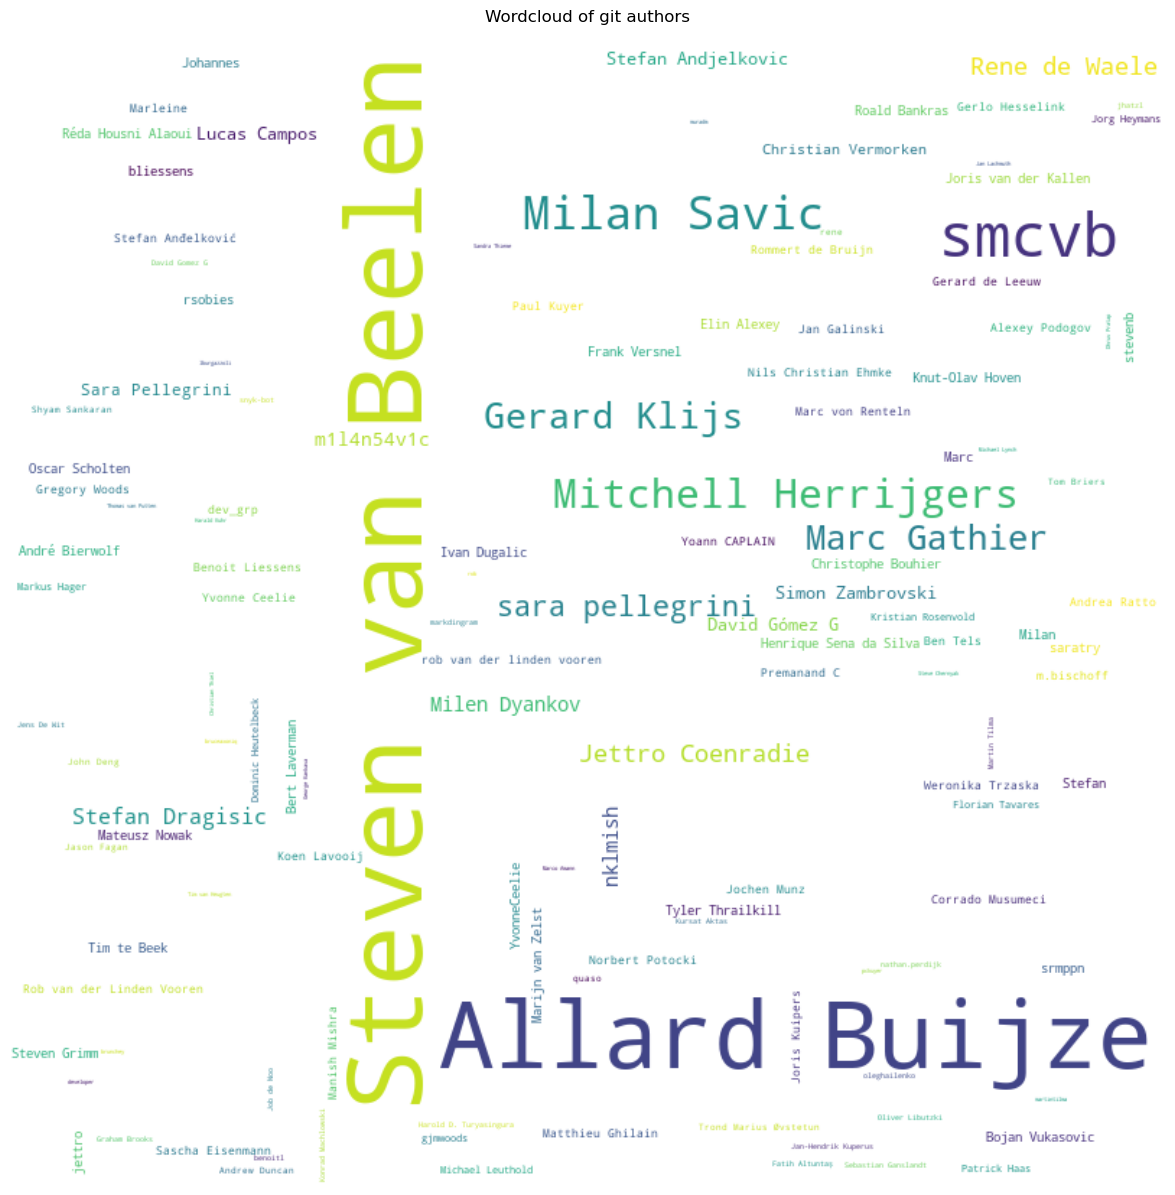

In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plot

if not git_author_words_with_frequency.empty:
    # Expects the first column of the DataFrame to contain the words/text and the second column to contain the count/frequency.
    words_with_frequency_dict=git_author_words_with_frequency.set_index(git_author_words_with_frequency.columns[0]).to_dict()[git_author_words_with_frequency.columns[1]]
    wordcloud = WordCloud(
        width=800, 
        height=800,
        max_words=600, 
        collocations=False,
        background_color='white', 
        colormap='viridis'
    ).generate_from_frequencies(words_with_frequency_dict)

    # Plot the word cloud
    plot.figure(figsize=(15,15))
    plot.imshow(wordcloud, interpolation='bilinear')
    plot.axis("off")
    plot.title('Wordcloud of git authors')
    plot.show()